# Cognition and Computation - Individual Project

## EMNIST Letters: visual concept learning with a Deep Belief Network

**Student name:**  
**Student ID:**  
**Date:**  

This project studies visual concept learning on **EMNIST Letters**, and use a Deep Belief Network because it allows me to inspect internal representations at different depths, since the project is not only focused on obtaining high accuracy, but also on understanding what kind of visual structure the DBN learns and how stable these representations are under different testing conditions.


The notebook structure is organized as follows:

1. Setup of the DBN code, libraries, device, random seeds, and loading of the EMNIST Letters dataset.
2. Preliminary comparison of different DBN architectures.
3. Selection and training of the final DBN architecture.
4. Visualization of receptive fields and projected receptive fields.
5. Extraction of hidden representations from H1, H2 and H3.
6. Computation of reconstruction errors as a sanity check for RBM pre-training.
7. Standardization of input and hidden representations before linear read-outs.
8. Hierarchical clustering of average class representations.
9. Training and evaluation of linear read-outs on input pixels, H1, H2 and H3.
10. Analysis of normalized confusion matrices across hidden representations.
11. Construction of psychometric curves with Gaussian noise and salt-and-pepper noise.
12. Training of a fully supervised feed-forward neural network baseline.
13. Evaluation of robustness under white-box FGSM adversarial attacks.
14. Analysis of transfer attacks from the FFNN to the DBN read-out.
15. Simple noisy-data augmentation strategy and robustness evaluation.
16. Final discussion of the main results, limitations and possible improvements.

## Model and main idea

In this project I use a Deep Belief Network composed of three stacked RBMs. I use three hidden layers because this allows to analyze three different levels of internal representation, H1, H2 and H3, while keeping the model interpretable and computationally feasible.


Since the exact number of hidden units is not fixed a priori, I compare different architectural configurations in a preliminary model-selection step, for the purpose to test whether an expanding, compressive, or constant-size hierarchy produces more useful representations for EMNIST Letters.

The general goal of the project is to understand whether a DBN can learn useful, structured and robust internal representations of handwritten letters. In particular, I want to investigate whether the original pixel representation is transformed into hidden representations that are easier to classify with simple linear read-outs, meanwhile, the project also explores some architectural questions, in the specific, it's made a comparison among different DBN configurations to see whether an expanding, compressive or constant-size hierarchy works better for EMNIST Letters.

This allows me to test whether changing the number of hidden units across layers affects the quality of the learned representations, the classification accuracy and the robustness of the model, this is why the project put a focus not only to mere accuracy, but even on understand how architectural choices, internal representations and robustness are related.





---



## 1. Setup of the DBN code, libraries, device, random seeds, and loading of the EMNIST Letters dataset

In [1]:
# 1. DBN code
from pathlib import Path
from urllib.request import urlretrieve
def get_dbn_library():
    files = ["DBN.py", "RBM.py"]
    repository_url = "https://raw.githubusercontent.com/flavio2018/Deep-Belief-Network-pytorch/master/"

    for file in files:
        file_path = Path(file)

        if not file_path.exists():
            print("Downloading", file)
            urlretrieve(repository_url + file, file_path)
        else:
            print(file, "already exists")

get_dbn_library()

DBN.py already exists
RBM.py already exists


In [2]:
#Libraries
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.cluster as cluster
from scipy.spatial.distance import pdist, squareform
import sklearn.preprocessing
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import torch
import torch.nn.functional as functional
import torchvision as tv
from torch.utils.data import TensorDataset, DataLoader
from tqdm.auto import tqdm
from DBN import DBN


In [3]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

print("CUDA available:", torch.cuda.is_available())
print("Device:", device)


torch.manual_seed(0)
np.random.seed(0)

CUDA available: True
Device: cuda


In [4]:
# Load EMNIST Letters train/test sets

emnist_tr = tv.datasets.EMNIST(
    root="./data",
    split="letters",
    train=True,
    download=True
)

emnist_te = tv.datasets.EMNIST(
    root="./data",
    split="letters",
    train=False,
    download=True
)

In [5]:
def fix_emnist_orientation(images):
    images = torch.rot90(images, k=3, dims=[1, 2])
    images = torch.flip(images, dims=[2])
    return images.contiguous()


x_train = fix_emnist_orientation(emnist_tr.data).float() / 255
x_test = fix_emnist_orientation(emnist_te.data).float() / 255

y_train = emnist_tr.targets.long() - 1
y_test = emnist_te.targets.long() - 1

num_classes = 26
class_names = [chr(ord("A") + i) for i in range(num_classes)]

print("Training images:", x_train.shape)
print("Training labels:", y_train.shape)
print("Test images:", x_test.shape)
print("Test labels:", y_test.shape)
print("Label range:", y_train.min().item(), y_train.max().item())

Training images: torch.Size([124800, 28, 28])
Training labels: torch.Size([124800])
Test images: torch.Size([20800, 28, 28])
Test labels: torch.Size([20800])
Label range: 0 25


The EMNIST Letters dataset was loaded correctly. The training set contains 124,800 images, while the test set contains 20,800 images. Each image has size 28×28 pixels.

Since EMNIST Letters originally uses labels from 1 to 26, I subtracted 1 from the targets so that the labels range from 0 to 25, which is the format required by PyTorch's `CrossEntropyLoss`. The 26 labels correspond to the letters A–Z.

I also corrected the orientation of the images, because EMNIST images are rotated and flipped when loaded with `torchvision`. This makes the examples easier to inspect visually and avoids interpreting wrongly oriented letters.

In [6]:
'''# Optional: use a smaller subset to test the code quickly.
# For the final run, keep use_small_subset = False.

use_small_subset = False

if use_small_subset:
    n_train = 15000
    n_test = 5000

    x_train = x_train[:n_train]
    y_train = y_train[:n_train]
    x_test = x_test[:n_test]
    y_test = y_test[:n_test]

    print("Using a smaller subset")
    print(x_train.shape, y_train.shape)
    print(x_test.shape, y_test.shape)'''

'# Optional: use a smaller subset to test the code quickly.\n# For the final run, keep use_small_subset = False.\n\nuse_small_subset = False\n\nif use_small_subset:\n    n_train = 15000\n    n_test = 5000\n\n    x_train = x_train[:n_train]\n    y_train = y_train[:n_train]\n    x_test = x_test[:n_test]\n    y_test = y_test[:n_test]\n\n    print("Using a smaller subset")\n    print(x_train.shape, y_train.shape)\n    print(x_test.shape, y_test.shape)'

In [7]:
# I decide to move the tensors to the selected device only after the optional subset selection.

x_train = x_train.to(device)
x_test = x_test.to(device)
y_train = y_train.to(device)
y_test = y_test.to(device)

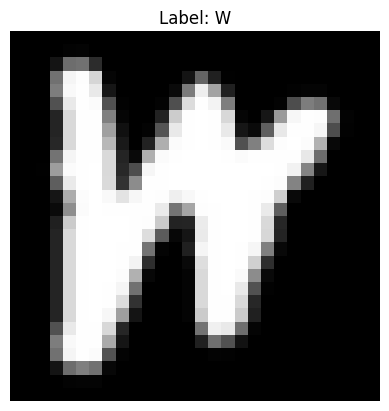

In [8]:
idx = 0

plt.imshow(x_train[idx].detach().cpu(), cmap="gray")
plt.title("Label: {}".format(class_names[y_train[idx].item()]))
plt.axis("off")
plt.show()

The example image confirms that the EMNIST orientation correction worked correctly. The letter is visually readable and the label matches the displayed class. This check is useful before training the model, because wrong image orientation could make the classification task harder and would also make the visualizations less interpretable.

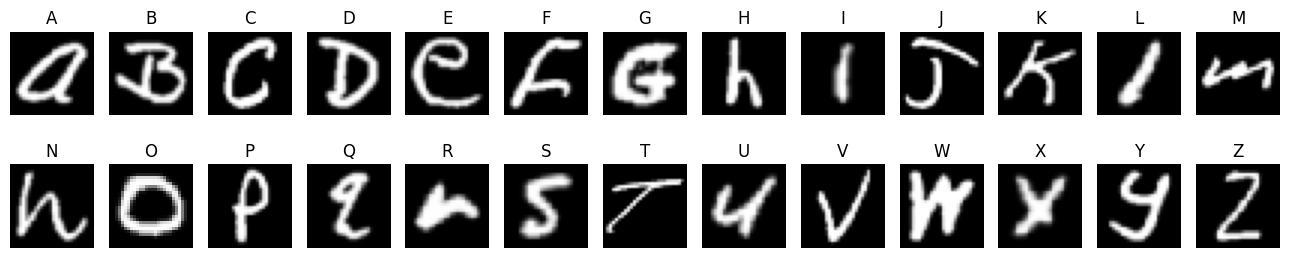

In [9]:
# One example for each letter.

fig, axes = plt.subplots(2, 13, figsize=(13, 3))

for label in range(num_classes):
    row = label // 13
    col = label % 13

    indices = (y_train == label).nonzero(as_tuple=True)[0]
    example_idx = indices[0]

    axes[row, col].imshow(x_train[example_idx].detach().cpu(), cmap="gray")
    axes[row, col].set_title(class_names[label])
    axes[row, col].axis("off")

plt.tight_layout()
plt.show()

Here is shown one example for each of the 26 EMNIST letter classes. The images are now correctly oriented, and each label corresponds to a letter from A to Z. Some letters are visually clear, while others are more ambiguous because of the handwritten style. This makes the task interesting, because some errors may depend on the visual similarity between letters.

## 2. Preliminary comparison of different DBN architectures
As a starting point, I used the lab architectural setting `400-500-800` as a baseline configuration. However, I did not assume that this architecture was necessarily optimal for EMNIST Letters. Instead, I compared it with two alternative configurations in order to test how the distribution of hidden units across the DBN hierarchy affects the quality of the learned representations.

Tthe number of hidden layers isn't increased beyond three, in order to follow project goal of analyze how representations change across a small hierarchy and not to build the deepest possible model.
Three hidden layers provide a good compromise between interpretability, computational cost, and the possibility of comparing H1, H2 and H3.

The three architectures were chosen to test different hypotheses about representational capacity. The architecture `400-500-800` tests an "expanding" configuration, where the number of hidden units increases in deeper layers. The architecture `800-500-400` tests a "compressive" configuration, where the representation is progressively reduced. The architecture `500-500-500` serves as a neutral baseline, because the number of units is kept constant across layers.

The evaluation of the candidate architectures is made using linear read-outs from H1, H2 and H3 under clean and noisy validation conditions, in particular, I use Gaussian noise  to evaluate robustness to continuous pixel-level perturbations and salt-and-pepper noise as an additional degradation condition. Adversarial perturbations are not included in this preliminary comparison, because they depend on additional choices such as the attacked layer, the read-out classifier and the epsilon value. For this reason, adversarial robustness is analyzed later only on the final selected architecture.

The selection score is computed as the average of the hidden-layer read-out accuracies across the three conditions:

`selection_score = (mean_clean_accuracy + mean_gaussian_accuracy + mean_salt_pepper_accuracy) / 3`

The architecture with the highest selection score is selected for the full representational analysis.

In [10]:
# Create a balanced train/validation split for architecture comparison.

def create_balanced_split(images, labels, n_train_per_class=500, n_val_per_class=150, seed=0):
    generator = torch.Generator(device="cpu")
    generator.manual_seed(seed)

    labels_cpu = labels.detach().cpu()

    train_indices = []
    val_indices = []

    for class_idx in range(num_classes):
        class_indices = (labels_cpu == class_idx).nonzero(as_tuple=True)[0]
        shuffled_indices = class_indices[torch.randperm(len(class_indices), generator=generator)]

        train_indices.append(shuffled_indices[:n_train_per_class])
        val_indices.append(shuffled_indices[n_train_per_class:n_train_per_class + n_val_per_class])

    train_indices = torch.cat(train_indices).to(images.device)
    val_indices = torch.cat(val_indices).to(images.device)

    return images[train_indices], labels[train_indices], images[val_indices], labels[val_indices]


In [11]:
x_train_arch, y_train_arch, x_val_arch, y_val_arch = create_balanced_split(
    x_train,
    y_train,
    n_train_per_class=500,
    n_val_per_class=150,
    seed=0
)

### Define helper functions used to train DBNs, extract representations and train linear read-outs.


In [12]:
def create_dbn(hidden_units):
    return DBN(
        visible_units=28 * 28,
        hidden_units=hidden_units,
        k=1,
        learning_rate=0.01,
        learning_rate_decay=False,
        initial_momentum=0.5,
        final_momentum=0.95,
        weight_decay=0.0001,
        xavier_init=False,
        increase_to_cd_k=False,
        use_gpu=torch.cuda.is_available()
    )


def get_layer_representation(dbn, input_data, layer_index):
    input_data = input_data.view(input_data.shape[0], -1).float().to(device)
    hidden_sample, hidden_probability = dbn.rbm_layers[layer_index].to_hidden(input_data)
    return hidden_probability


def get_all_representations(dbn, images):
    h1 = get_layer_representation(dbn, images, 0)
    h2 = get_layer_representation(dbn, h1, 1)
    h3 = get_layer_representation(dbn, h2, 2)

    return {
        "H1": h1,
        "H2": h2,
        "H3": h3
    }

In [13]:
class LinearReadout(torch.nn.Module):
    def __init__(self, input_size, num_classes):
        super().__init__()
        self.linear = torch.nn.Linear(input_size, num_classes)

    def forward(self, x):
        return self.linear(x)


In [14]:

def fit_standardizer(train_repr):
    mean = train_repr.mean(dim=0, keepdim=True)
    std = train_repr.std(dim=0, unbiased=False, keepdim=True)

    std = torch.where(std < 1e-6, torch.ones_like(std), std)

    return mean, std


def apply_standardizer(data, mean, std):
    return (data - mean) / std


def standardize_train_test(train_repr, test_repr):
    mean, std = fit_standardizer(train_repr)

    train_scaled = apply_standardizer(train_repr, mean, std)
    test_scaled = apply_standardizer(test_repr, mean, std)

    stats = {
        "mean": mean,
        "std": std
    }

    return train_scaled, test_scaled, stats


def train_readout(train_data, train_labels, input_size, epochs=300, learning_rate=0.05):
    model = LinearReadout(input_size, num_classes).to(device)

    optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
    loss_function = torch.nn.CrossEntropyLoss()

    for epoch in range(epochs):
        optimizer.zero_grad()

        predictions = model(train_data)
        loss = loss_function(predictions, train_labels)

        loss.backward()
        optimizer.step()

    return model


def compute_accuracy(model, data, labels):
    with torch.no_grad():
        predictions = model(data)
        predicted_labels = predictions.argmax(dim=1)
        accuracy = (predicted_labels == labels).float().mean().item()

    return accuracy


def add_gaussian_noise(images, noise_level):
    noisy_images = images + torch.randn_like(images) * noise_level
    noisy_images = torch.clamp(noisy_images, 0, 1)

    return noisy_images


def add_salt_pepper_noise(images, noise_level):
    noisy_images = images.clone()

    random_values = torch.rand_like(noisy_images)

    noisy_images[random_values < noise_level / 2] = 0
    noisy_images[random_values > 1 - noise_level / 2] = 1

    return noisy_images

In [15]:
def evaluate_input_baseline(readout_epochs=300):
    x_train_flat = x_train_arch.view(x_train_arch.shape[0], -1)
    x_val_flat = x_val_arch.view(x_val_arch.shape[0], -1)

    x_val_gaussian = add_gaussian_noise(x_val_arch, noise_level=0.20)
    x_val_salt_pepper = add_salt_pepper_noise(x_val_arch, noise_level=0.08)

    x_val_gaussian_flat = x_val_gaussian.view(x_val_gaussian.shape[0], -1)
    x_val_salt_pepper_flat = x_val_salt_pepper.view(x_val_salt_pepper.shape[0], -1)

    train_scaled, val_clean_scaled, stats = standardize_train_test(
        x_train_flat,
        x_val_flat
    )

    val_gaussian_scaled = apply_standardizer(
        x_val_gaussian_flat,
        stats["mean"],
        stats["std"]
    )

    val_salt_pepper_scaled = apply_standardizer(
        x_val_salt_pepper_flat,
        stats["mean"],
        stats["std"]
    )

    readout = train_readout(
        train_scaled,
        y_train_arch,
        input_size=train_scaled.shape[1],
        epochs=readout_epochs,
        learning_rate=0.05
    )

    result = {
        "clean_Input": compute_accuracy(readout, val_clean_scaled, y_val_arch),
        "gaussian_Input": compute_accuracy(readout, val_gaussian_scaled, y_val_arch),
        "salt_pepper_Input": compute_accuracy(readout, val_salt_pepper_scaled, y_val_arch)
    }

    return result


input_baseline_results = evaluate_input_baseline(readout_epochs=300)

print(input_baseline_results)

{'clean_Input': 0.6805127859115601, 'gaussian_Input': 0.05076922848820686, 'salt_pepper_Input': 0.126923069357872}


In [16]:

def evaluate_architecture(hidden_units, dbn_epochs=15, readout_epochs=300):
    print("Training DBN architecture:", hidden_units)

    dbn = create_dbn(hidden_units)

    dbn.train_static(
        x_train_arch,
        y_train_arch,
        dbn_epochs,
        batch_size=125
    )
    train_representations = get_all_representations(dbn, x_train_arch)
    val_representations_clean = get_all_representations(dbn, x_val_arch)

    x_val_gaussian = add_gaussian_noise(x_val_arch, noise_level=0.20)
    x_val_salt_pepper = add_salt_pepper_noise(x_val_arch, noise_level=0.08)

    val_representations_gaussian = get_all_representations(dbn, x_val_gaussian)
    val_representations_salt_pepper = get_all_representations(dbn, x_val_salt_pepper)

    result = {
        "architecture": "-".join([str(value) for value in hidden_units])
    }

    clean_accuracies = []
    gaussian_accuracies = []
    salt_pepper_accuracies = []

    for layer_name in ["H1", "H2", "H3"]:
        train_data = train_representations[layer_name]
        val_data_clean = val_representations_clean[layer_name]
        val_data_gaussian = val_representations_gaussian[layer_name]
        val_data_salt_pepper = val_representations_salt_pepper[layer_name]

        train_data_scaled, val_data_clean_scaled, stats = standardize_train_test(
            train_data, val_data_clean )

        val_data_gaussian_scaled = apply_standardizer(
            val_data_gaussian, stats["mean"], stats["std"] )

        val_data_salt_pepper_scaled = apply_standardizer( val_data_salt_pepper
                ,stats["mean"], stats["std"] )

        readout = train_readout(
            train_data_scaled,
            y_train_arch,
            input_size=train_data_scaled.shape[1],
            epochs=readout_epochs,
            learning_rate=0.05
        )

        clean_accuracy = compute_accuracy(readout, val_data_clean_scaled, y_val_arch)
        gaussian_accuracy = compute_accuracy(readout, val_data_gaussian_scaled, y_val_arch)
        salt_pepper_accuracy = compute_accuracy(readout, val_data_salt_pepper_scaled, y_val_arch)

        result["clean_" + layer_name] = clean_accuracy
        result["gaussian_" + layer_name] = gaussian_accuracy
        result["salt_pepper_" + layer_name] = salt_pepper_accuracy

        clean_accuracies.append(clean_accuracy)
        gaussian_accuracies.append(gaussian_accuracy)
        salt_pepper_accuracies.append(salt_pepper_accuracy)

    result["mean_clean_accuracy"] = np.mean(clean_accuracies)
    result["mean_gaussian_accuracy"] = np.mean(gaussian_accuracies)
    result["mean_salt_pepper_accuracy"] = np.mean(salt_pepper_accuracies)

    result["selection_score"] = (
        result["mean_clean_accuracy"] +
        result["mean_gaussian_accuracy"] +
        result["mean_salt_pepper_accuracy"]
    ) / 3

    return result

### Train and evaluate each candidate architecture and select the best one.


Training DBN architecture: [400, 500, 800]
--------------------
Training RBM layer 1
|Epoch |avg_rec_err |std_rec_err  |mean_grad |std_grad  |
|10    |2.2125     |0.5421       |108.5560   |9.4516     |
--------------------
Training RBM layer 2
|Epoch |avg_rec_err |std_rec_err  |mean_grad |std_grad  |
|10    |3.2193     |0.3895       |78.1227   |4.6056     |
--------------------
Training RBM layer 3
|Epoch |avg_rec_err |std_rec_err  |mean_grad |std_grad  |
|10    |2.3313     |0.3369       |109.5433   |6.0847     |
Training DBN architecture: [500, 500, 500]
--------------------
Training RBM layer 1
|Epoch |avg_rec_err |std_rec_err  |mean_grad |std_grad  |
|10    |2.0865     |0.4905       |121.6280   |8.2600     |
--------------------
Training RBM layer 2
|Epoch |avg_rec_err |std_rec_err  |mean_grad |std_grad  |
|10    |2.8546     |0.3635       |90.2719   |4.2214     |
--------------------
Training RBM layer 3
|Epoch |avg_rec_err |std_rec_err  |mean_grad |std_grad  |
|10    |2.2449     |0

,architecture,clean_H1,gaussian_H1,salt_pepper_H1,clean_H2,gaussian_H2,salt_pepper_H2,clean_H3,gaussian_H3,salt_pepper_H3,mean_clean_accuracy,mean_gaussian_accuracy,mean_salt_pepper_accuracy,selection_score
0,800-500-400,0.689744,0.446410,0.610513,0.667179,0.508205,0.629744,0.645641,0.495641,0.606410,0.667521,0.483419,0.615556,0.588832
1,400-500-800,0.666667,0.435897,0.591795,0.655641,0.503846,0.605128,0.641795,0.483077,0.600513,0.654701,0.474273,0.599145,0.576040
2,500-500-500,0.667436,0.426667,0.592820,0.661795,0.501282,0.610769,0.642308,0.480256,0.594615,0.657179,0.469402,0.599402,0.575328


Selected architecture: [800, 500, 400]


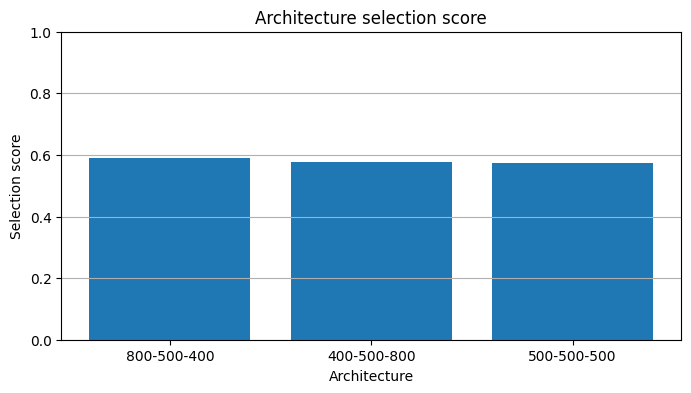

In [17]:
candidate_architectures = [
    [400, 500, 800],
    [500, 500, 500],
    [800, 500, 400]
]

architecture_results = []

for hidden_units in candidate_architectures:
    result = evaluate_architecture(
        hidden_units,
        dbn_epochs=15,
        readout_epochs=300
    )

    architecture_results.append(result)

architecture_results = pd.DataFrame(architecture_results)
architecture_results = architecture_results.sort_values("selection_score", ascending=False).reset_index(drop=True)

display(architecture_results)

best_architecture_string = architecture_results.iloc[0]["architecture"]
selected_hidden_units = [int(value) for value in best_architecture_string.split("-")]

print("Selected architecture:", selected_hidden_units)


plt.figure(figsize=(8, 4))

plt.bar(
    architecture_results["architecture"],
    architecture_results["selection_score"]
)

plt.ylim(0, 1)
plt.ylabel("Selection score")
plt.xlabel("Architecture")
plt.title("Architecture selection score")
plt.grid(axis="y")
plt.show()

### Result of the architecture comparison

Based on the selection score, the selected architecture is `800-500-400`. This architecture obtained the best compromise between clean validation accuracy and robustness to Gaussian and salt-and-pepper noise.

An important result is that the best architecture is not the one with more units in the deepest layer. This architecture `400-500-800` (score of 0.411) gives more capacity to H3, while the selected architecture `800-500-400` (highest score around 0.436 ) gives more capacity to H1 and then progressively compresses the representation. This suggests that, for EMNIST Letters, having a rich first hidden representation might be more useful than increasing the number of units in the deepest layer.

The results also show that depth alone does not guarantee better performance. The read-out accuracy does not increase monotonically from H1 to H3 in the preliminary comparison. Therefore, the distribution of hidden units across layers seems to matter, and all the following analyses are performed on the selected `800-500-400` DBN architecture.

## 3. Selection and training of the final DBN architecture

The selected architecture for the full DBN analysis is `800-500-400`, and has 784 visible units, corresponding to the 28×28 input pixels, and three hidden layers.

The number of training epochs was set to 60 based on l convergence criterion. I see the change in performance across training checkpoints and observed that, between 50 and 60 epochs, the relative improvement was already less or equal to 1%.

This architecture is then used for the following analyses: receptive fields, reconstruction error, clustering, linear read-outs, confusion matrices, psychometric curves and adversarial robustness.

The goal of training this final DBN is not only to obtain a classifier, but to study whether the hidden representations learned by the model are useful, interpretable and robust for EMNIST letter recognition.

In [18]:
dbn_emnist = DBN(
    visible_units=28 * 28,
    hidden_units=selected_hidden_units,
    k=1,
    learning_rate=0.01,
    learning_rate_decay=False,
    initial_momentum=0.5,
    final_momentum=0.95,
    weight_decay=0.0001,
    xavier_init=False,
    increase_to_cd_k=False,
    use_gpu=torch.cuda.is_available()
)

In [19]:
num_epochs = 60
batch_size = 125

dbn_emnist.train_static(
    x_train,
    y_train,
    num_epochs,
    batch_size
)

--------------------
Training RBM layer 1
|Epoch |avg_rec_err |std_rec_err  |mean_grad |std_grad  |
|10    |1.2558     |0.0382       |69.8498   |1.5774     |
|20    |1.1617     |0.0326       |64.5922   |1.4826     |
|30    |1.1321     |0.0314       |62.9879   |1.5531     |
|40    |1.1136     |0.0318       |61.5617   |1.3964     |
|50    |1.1022     |0.0301       |60.2285   |1.3203     |
|60    |1.0946     |0.0300       |59.6820   |1.2274     |
--------------------
Training RBM layer 2
|Epoch |avg_rec_err |std_rec_err  |mean_grad |std_grad  |
|10    |1.0876     |0.0296       |56.4126   |1.1395     |
|20    |0.9448     |0.0235       |52.6042   |1.0459     |
|30    |0.9271     |0.0220       |52.0486   |1.0180     |
|40    |0.9198     |0.0220       |51.8657   |0.9974     |
|50    |0.9152     |0.0221       |51.5515   |0.9918     |
|60    |0.9136     |0.0222       |51.6285   |0.8176     |
--------------------
Training RBM layer 3
|Epoch |avg_rec_err |std_rec_err  |mean_grad |std_grad  |
|10 

### Training results and interpretation
The DBN training is completed for all three RBM layers. Within each RBM, the average reconstruction error generally decreases across epochs, which suggests that the layer-wise pre-training is working and that each RBM is learning to reconstruct its input more accurately.

However, these reconstruction errors should be interpreted only as a preliminary sanity check. They are not the main evaluation metric because the real quality of the learned representations will be evaluated later through read-outs, clustering, confusion matrices and robustness tests.

## 4. Visualization of receptive fields and projected receptive fields

In [20]:
# Functions to visualize first-layer receptive fields

def get_weights(dbn, layer):
    return dbn.rbm_layers[layer].W.detach().cpu().numpy()

def apply_threshold(weights, threshold=0):
    return weights * (np.abs(weights) > threshold)

def apply_min_max_scaler(learned_weights):
    original_shape = learned_weights.shape

    min_max_scaler = sklearn.preprocessing.MinMaxScaler()
    scaled = min_max_scaler.fit_transform(learned_weights.ravel().reshape(-1, 1))
    scaled = scaled.reshape(original_shape)

    return scaled

def plot_layer_receptive_fields(weights, title="", num_subplots=100):
    n_rows_cols = int(math.sqrt(num_subplots))

    fig, axes = plt.subplots(
        n_rows_cols,
        n_rows_cols,
        sharex=True,
        sharey=True,
        figsize=(10, 10)
    )

    for i in range(num_subplots):
        row = i % n_rows_cols
        col = i // n_rows_cols

        # Each hidden unit corresponds to one column of the weight matrix
        receptive_field = weights[:, i]

        axes[row, col].imshow(receptive_field.reshape((28, 28)), cmap=plt.cm.gray)
        axes[row, col].axis("off")

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

These functions are used to visualize the receptive fields of the first RBM layer. Since the first layer connects the original pixels to hidden units, each hidden unit can be represented as a 28×28 image.

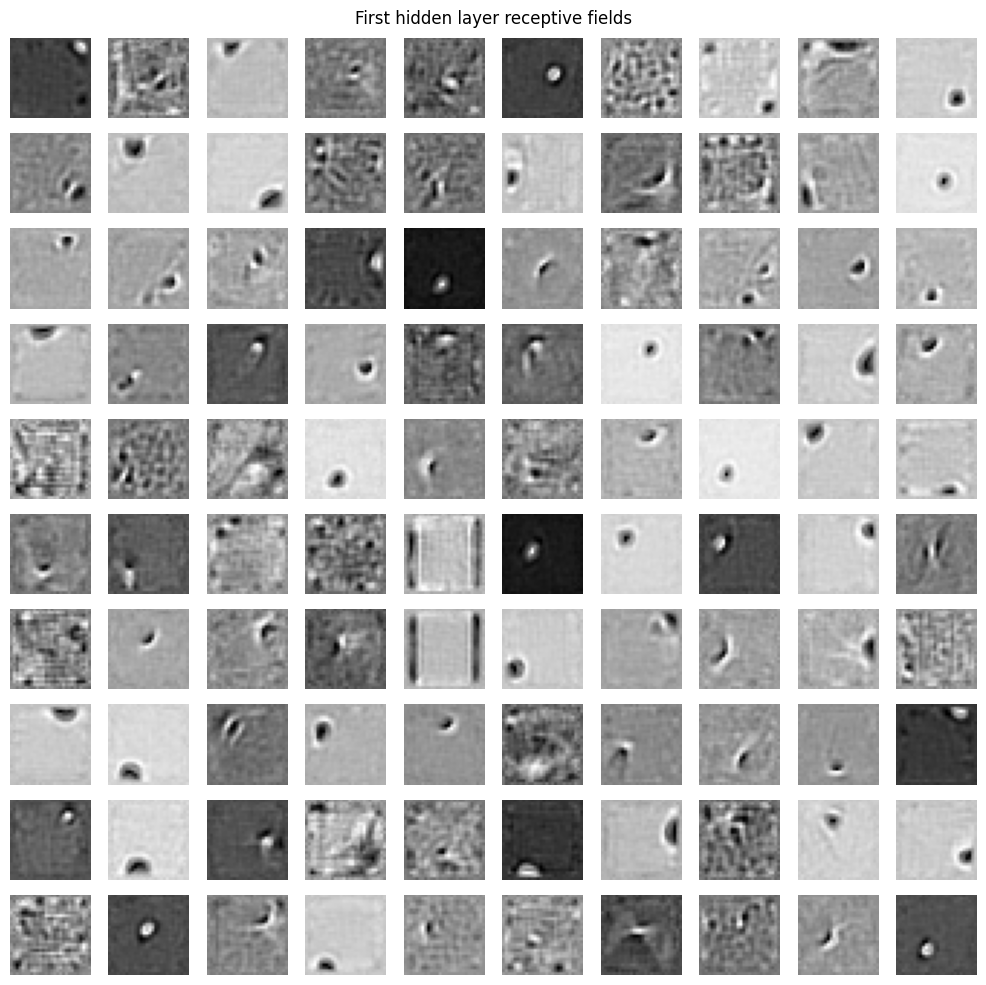

In [21]:
weights_first_layer = get_weights(dbn_emnist, layer=0)
weights_first_layer = apply_threshold(weights_first_layer, threshold=0)
weights_first_layer = apply_min_max_scaler(weights_first_layer)

plot_layer_receptive_fields(
    weights_first_layer,
    title="First hidden layer receptive fields"
)

W1 shape: (784, 800)
W2 shape: (800, 500)
W3 shape: (500, 400)


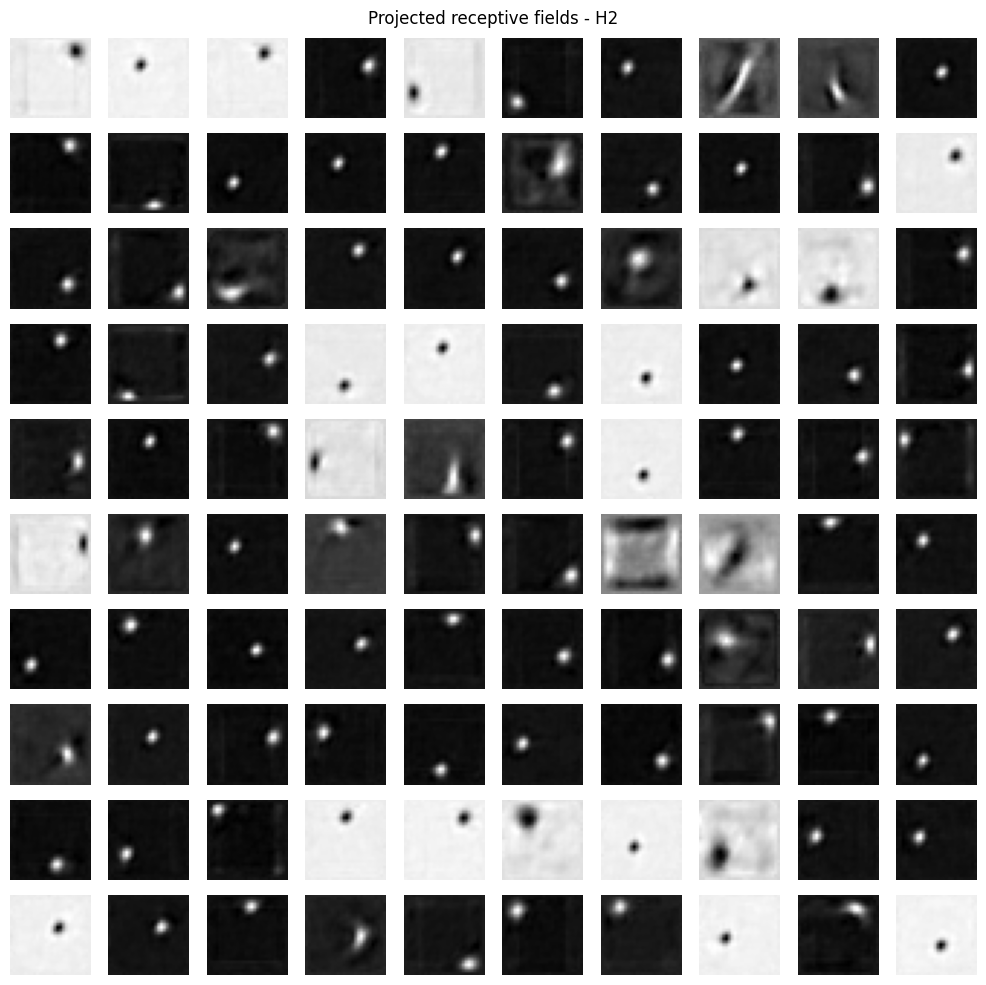

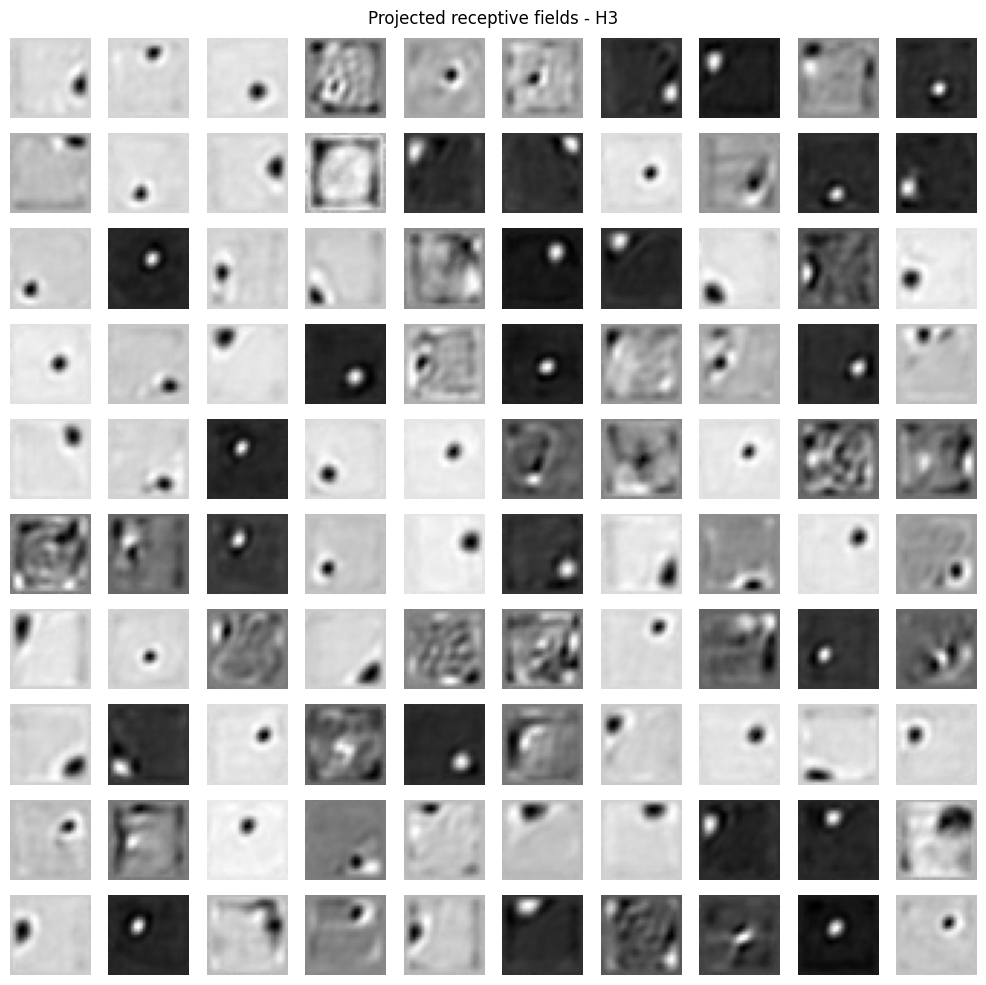

In [22]:
# Projected receptive fields for deeper layers

# Get the original weights again, without thresholding or rescaling
w1 = get_weights(dbn_emnist, layer=0)
w2 = get_weights(dbn_emnist, layer=1)
w3 = get_weights(dbn_emnist, layer=2)

print("W1 shape:", w1.shape)
print("W2 shape:", w2.shape)
print("W3 shape:", w3.shape)

# Project H2 weights back into pixel space
projected_h2 = w1 @ w2
projected_h2 = apply_threshold(projected_h2, threshold=0)
projected_h2 = apply_min_max_scaler(projected_h2)

plot_layer_receptive_fields(
    projected_h2,
    title="Projected receptive fields - H2"
)

# Project H3 weights back into pixel space
projected_h3 = w1 @ w2 @ w3
projected_h3 = apply_threshold(projected_h3, threshold=0)
projected_h3 = apply_min_max_scaler(projected_h3)

plot_layer_receptive_fields(
    projected_h3,
    title="Projected receptive fields - H3"
)



The first-layer receptive fields mainly capture local visual patterns, such as strokes, edges and curves. This is expected because H1 is directly connected to the pixel input. For H2 and H3, I projected the weights back into pixel space using `W1 @ W2` and `W1 @ W2 @ W3`, so these visualizations should be interpreted cautiously. Compared with H1, the deeper projected receptive fields are more distributed and less directly interpretable. This suggests that later layers combine lower-level features into more complex representations rather than clear letter templates. Overall, these plots suggest a hierarchical representation, but the hidden layers are evaluated more directly through clustering, linear read-outs, confusion matrices and robustness analyses.

## 5. Extraction of hidden representations from H1, H2 and H3
In this section are extracted hidden representations produced by the three RBM layers of the selected DBN architecture. These representations will be used in the following analyses, including clustering, linear read-outs, confusion matrices and robustness tests

In [23]:
def get_kth_layer_repr(input_data, k, device, deterministic=True):
    flattened_input = input_data.view((input_data.shape[0], -1)).float().to(device)

    hidden_sample, hidden_probability = dbn_emnist.rbm_layers[k].to_hidden(flattened_input)

    if deterministic:
        return hidden_probability

    return hidden_sample

In [24]:
h1_train = get_kth_layer_repr(x_train, 0, device)
h2_train = get_kth_layer_repr(h1_train, 1, device)
h3_train = get_kth_layer_repr(h2_train, 2, device)

h1_test = get_kth_layer_repr(x_test, 0, device)
h2_test = get_kth_layer_repr(h1_test, 1, device)
h3_test = get_kth_layer_repr(h2_test, 2, device)

print("H1 train:", h1_train.shape)
print("H2 train:", h2_train.shape)
print("H3 train:", h3_train.shape)

H1 train: torch.Size([124800, 800])
H2 train: torch.Size([124800, 500])
H3 train: torch.Size([124800, 400])


 I use hidden activation probabilities instead of stochastic samples, because this gives more stable representations for the following analyses. The printed tensor shapes confirm the dimensionality of H1, H2 and H3.

## 6. Computation of reconstruction errors as a sanity check for RBM pre-training

In [25]:
def reconstruction_error_rbm(rbm_layer, input_data, batch_size=256):
    dataset = TensorDataset(input_data)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    errors = []

    with torch.no_grad():
        for (batch_data,) in loader:
            batch_data = batch_data.to(device)
            batch_data = batch_data.view(batch_data.shape[0], -1).float()

            hidden, _ = rbm_layer.to_hidden(batch_data)
            reconstructed, _ = rbm_layer.to_visible(hidden)

            error = torch.mean((batch_data - reconstructed) ** 2)
            errors.append(error.item())

    return np.mean(errors)

In [26]:
err_layer1 = reconstruction_error_rbm(dbn_emnist.rbm_layers[0], x_train)
err_layer2 = reconstruction_error_rbm(dbn_emnist.rbm_layers[1], h1_train)
err_layer3 = reconstruction_error_rbm(dbn_emnist.rbm_layers[2], h2_train)

reconstruction_results = pd.DataFrame({
    "Layer": ["RBM 1", "RBM 2", "RBM 3"],
    "Reconstruction error": [err_layer1, err_layer2, err_layer3]
})

print(reconstruction_results)

   Layer  Reconstruction error
0  RBM 1              0.002538
1  RBM 2              0.095048
2  RBM 3              0.044017


### Interpretation: reconstruction error

The reconstruction error is used here as a sanity check for RBM pre-training. RBM 1 obtains the lowest reconstruction error,around 0.002, suggesting that the first layer is able to reconstruct the original pixel-level input quite accurately,  while RBM 2 shows the highest value, while  RBM 3 shows value lower than RBM 3, respectively 0.095 and 0.044 .

The higher errors in RBM 2 and RBM 3 should not be interpreted as a failure of deeper layers, because each RBM reconstructs a different type of input: RBM 1 reconstructs image pixels, whereas RBM 2 and RBM 3 reconstruct hidden representations from the previous layers. Therefore, the reconstruction errors are not directly comparable across layers.

Overall, reconstruction error is useful as a preliminary check that RBM pre-training is working, but it should not be treated as a direct measure of representational quality.


## 7. Standardization of input and hidden representations before linear read-outs

Before training the linear read-outs, I standardize the input representations. This is useful because the activations of different layers may have different scales. The standardization parameters are computed only on the training set and then applied to the test set, to avoid using information from the test data during training.



In [27]:

# The functions fit_standardizer, apply_standardizer and standardize_train_test
# were already defined in the preliminary architecture comparison section.

x_train_flat = x_train.view(x_train.shape[0], -1)
x_test_flat = x_test.view(x_test.shape[0], -1)

input_train_scaled, input_test_scaled, input_stats = standardize_train_test(x_train_flat, x_test_flat)
h1_train_scaled, h1_test_scaled, h1_stats = standardize_train_test(h1_train, h1_test)
h2_train_scaled, h2_test_scaled, h2_stats = standardize_train_test(h2_train, h2_test)
h3_train_scaled, h3_test_scaled, h3_stats = standardize_train_test(h3_train, h3_test)

## 8. Hierarchical clustering of average class representations
For the clustering analysis, I compute the average class representation for each letter class, then apply hierarchical clustering to see whether letters with similar internal representations are grouped together. This analysis gives a qualitative view of the structure learned by the DBN, beyond classification accuracy.

In [28]:
def get_mask(labels, target_label):
    labels_np = labels.detach().cpu().numpy()
    return labels_np == target_label

def get_label_to_mean_hidden_repr(hidden_repr, labels, num_classes):
    hidden_repr_np = hidden_repr.detach().cpu().numpy()

    label_to_mean = {}

    for label in range(num_classes):
        mask = get_mask(labels, label)
        label_to_mean[label] = hidden_repr_np[mask].mean(axis=0)

    return label_to_mean

def get_hidden_reprs_matrix(hidden_repr, labels, num_classes):
    label_to_mean = get_label_to_mean_hidden_repr(hidden_repr, labels, num_classes)

    matrix = np.concatenate([
        np.expand_dims(label_to_mean[label], axis=0)
        for label in range(num_classes)
    ])

    return matrix

def plot_dendrogram(mean_repr_matrix, title=""):
    fig, ax = plt.subplots(figsize=(12, 5))

    linkage = cluster.hierarchy.linkage(mean_repr_matrix, method="complete")

    cluster.hierarchy.dendrogram(
        linkage,
        labels=class_names,
        ax=ax
    )

    ax.set_title(title)
    ax.set_ylabel("Distance")
    plt.show()

def print_closest_letter_pairs(mean_repr_matrix, title="", top_n=10):
    distances = squareform(pdist(mean_repr_matrix))

    pairs = []
    for i in range(num_classes):
        for j in range(i + 1, num_classes):
            pairs.append((class_names[i], class_names[j], distances[i, j]))

    pairs = sorted(pairs, key=lambda x: x[2])

    print(title)
    print("Closest letter pairs:")
    for a, b, dist in pairs[:top_n]:
        print("{} - {} : {:.4f}".format(a, b, dist))

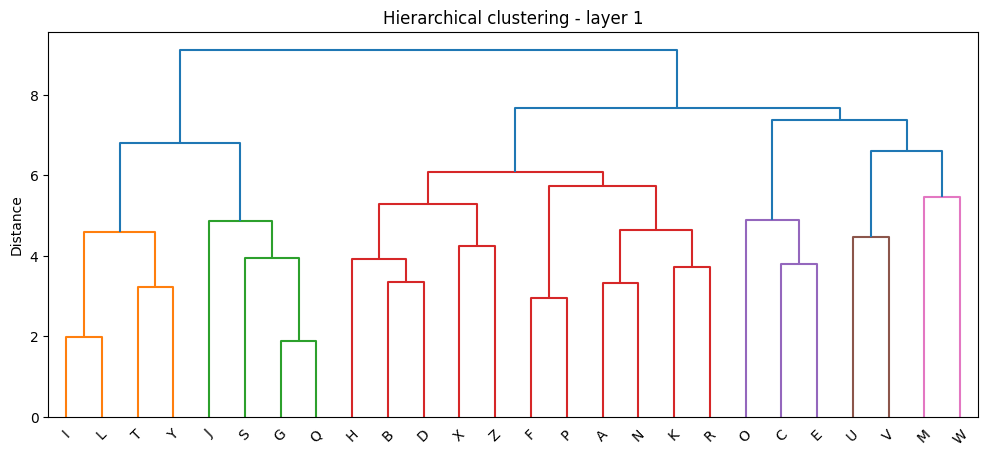

Layer 1
Closest letter pairs:
G - Q : 1.8810
I - L : 1.9714
F - P : 2.9408
G - S : 3.1807
T - Y : 3.2287
F - T : 3.2574
L - T : 3.2847
A - N : 3.3152
B - D : 3.3421
B - H : 3.3512


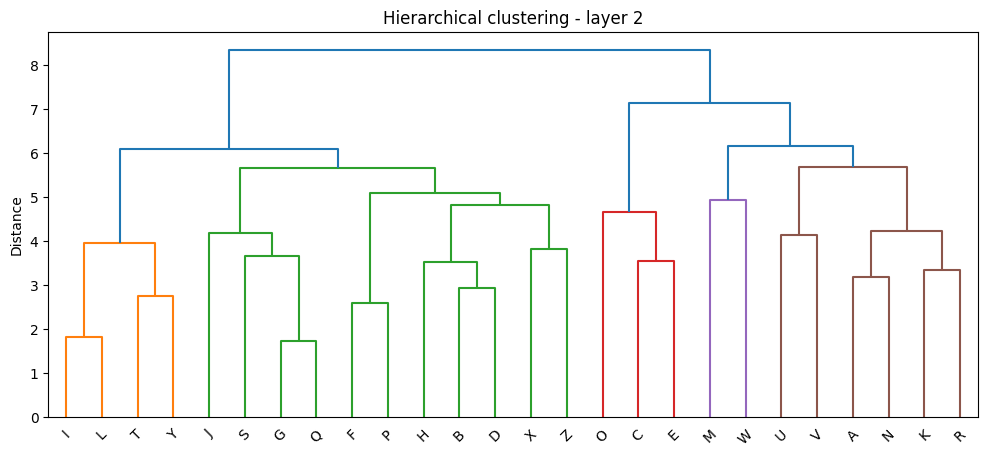

Layer 2
Closest letter pairs:
G - Q : 1.7253
I - L : 1.7988
F - P : 2.5886
T - Y : 2.7523
L - T : 2.7785
F - T : 2.8220
B - D : 2.9277
G - S : 3.0202
B - H : 3.0720
A - N : 3.1640


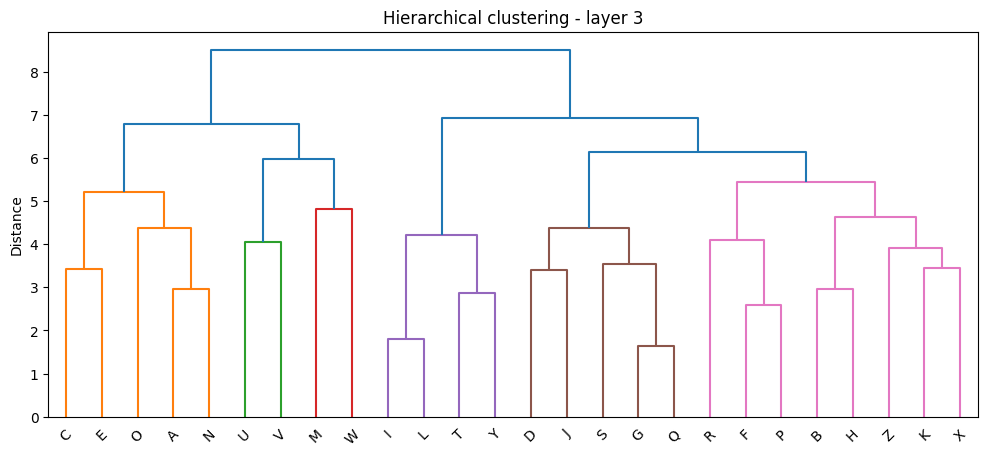

Layer 3
Closest letter pairs:
G - Q : 1.6414
I - L : 1.7898
F - P : 2.5951
G - S : 2.8504
T - Y : 2.8771
F - T : 2.8804
B - H : 2.9622
A - N : 2.9640
B - D : 3.0092
L - T : 3.0485


In [29]:
# For clustering I use the non-standardized hidden activations.
# This is closer to analyzing the representations produced by the DBN itself.

mean_h1 = get_hidden_reprs_matrix(h1_train, y_train, num_classes)
mean_h2 = get_hidden_reprs_matrix(h2_train, y_train, num_classes)
mean_h3 = get_hidden_reprs_matrix(h3_train, y_train, num_classes)

plot_dendrogram(mean_h1, title="Hierarchical clustering - layer 1")
print_closest_letter_pairs(mean_h1, title="Layer 1")

plot_dendrogram(mean_h2, title="Hierarchical clustering - layer 2")
print_closest_letter_pairs(mean_h2, title="Layer 2")

plot_dendrogram(mean_h3, title="Hierarchical clustering - layer 3")
print_closest_letter_pairs(mean_h3, title="Layer 3")

### Interpretation: hierarchical clustering

The dendrograms show how the average hidden representations of the 26 letter classes are organized across the different DBN layers. The clustering is not random: several visually similar letter pairs appear consistently close in H1, H2 and H3, suggesting that the model captures meaningful similarities between handwritten letters.

The clearest and stable examples recurring across H1, H2 and H3 are `G-Q`, `I-L` and `F-P`. These pairs are visually plausible because they share similar structural properties: `G` and `Q` both have a rounded shape, `I` and `L` can share simple vertical stroke components, and `F` and `P` both contain a vertical stem with an upper structure.

Other recurrent pairs, such as `A-N`, `B-D`, `T-Y`, `B-H` and `G-S`, also suggest that the DBN groups some letters according to similar stroke patterns and handwritten shapes. However, these similarities should be interpreted cautiously, because the DBN was trained in an unsupervised way and the clusters are based on average hidden representations rather than on explicit class labels during pre-training and consequently, clustering should not be interpreted as a direct measure of class separability.

It mainly shows that the learned representations preserve a structured organization of visual similarity, but it isn't sufficently informative, for this reason, I combine it with the linear read-out results, which provide a more direct test of how useful H1, H2 and H3 are for classification.

## 9. Training and evaluation of linear read-outs on input pixels, H1, H2 and H3
In this section, I train linear read-outs on the standardized pixel input and on the hidden representations extracted from H1, H2 and H3. The input read-out is used as a baseline, while the hidden-layer read-outs test whether the DBN representations become more linearly separable across the hierarchy. The DBN weights are kept fixed, so the read-outs evaluate the quality of the learned representations without fine-tuning the DBN itself.

In [30]:
linear_epochs = 1500
linear_lr = 0.05

class LinearModel(torch.nn.Module):
    def __init__(self, layer_size, num_classes):
        super().__init__()
        self.linear = torch.nn.Linear(layer_size, num_classes)

    def forward(self, x):
        return self.linear(x)

In [31]:
linear_input = LinearModel(input_train_scaled.shape[1], num_classes).to(device)
linear1 = LinearModel(h1_train_scaled.shape[1], num_classes).to(device)
linear2 = LinearModel(h2_train_scaled.shape[1], num_classes).to(device)
linear3 = LinearModel(h3_train_scaled.shape[1], num_classes).to(device)

In [32]:
def train_readout(network, input_data, targets, epochs, lr):
    optimizer = torch.optim.SGD(network.parameters(), lr=lr)
    loss_fun = torch.nn.CrossEntropyLoss()

    for epoch in range(epochs):
        optimizer.zero_grad()

        predictions = network(input_data).squeeze()
        loss = loss_fun(predictions, targets)

        loss.backward()
        optimizer.step()

        if epoch % 100 == 0:
            print("epoch : {:4d}/{}, loss = {:.4f}".format(epoch + 1, epochs, loss.item()))

def compute_accuracy(predictions, targets):
    predictions_indices = predictions.max(axis=1).indices
    accuracy = (predictions_indices == targets).sum() / len(targets)
    return accuracy.item()

In [34]:
print("Training input read-out")
train_readout(linear_input, input_train_scaled, y_train, epochs=linear_epochs, lr=linear_lr)

Training input read-out
epoch :    1/1500, loss = 3.4411
epoch :  101/1500, loss = 1.2390
epoch :  201/1500, loss = 1.1263
epoch :  301/1500, loss = 1.0821
epoch :  401/1500, loss = 1.0580
epoch :  501/1500, loss = 1.0426
epoch :  601/1500, loss = 1.0317
epoch :  701/1500, loss = 1.0236
epoch :  801/1500, loss = 1.0172
epoch :  901/1500, loss = 1.0120
epoch : 1001/1500, loss = 1.0077
epoch : 1101/1500, loss = 1.0040
epoch : 1201/1500, loss = 1.0007
epoch : 1301/1500, loss = 0.9979
epoch : 1401/1500, loss = 0.9953


In [35]:
print("Training H1 read-out")
train_readout(linear1, h1_train_scaled, y_train, epochs=linear_epochs, lr=linear_lr)

Training H1 read-out
epoch :    1/1500, loss = 3.5227
epoch :  101/1500, loss = 1.2580
epoch :  201/1500, loss = 1.0979
epoch :  301/1500, loss = 1.0216
epoch :  401/1500, loss = 0.9732
epoch :  501/1500, loss = 0.9385
epoch :  601/1500, loss = 0.9118
epoch :  701/1500, loss = 0.8905
epoch :  801/1500, loss = 0.8730
epoch :  901/1500, loss = 0.8583
epoch : 1001/1500, loss = 0.8458
epoch : 1101/1500, loss = 0.8349
epoch : 1201/1500, loss = 0.8254
epoch : 1301/1500, loss = 0.8171
epoch : 1401/1500, loss = 0.8097


In [36]:
print("Training H2 read-out")
train_readout(linear2, h2_train_scaled, y_train, epochs=linear_epochs, lr=linear_lr)

Training H2 read-out
epoch :    1/1500, loss = 3.3970
epoch :  101/1500, loss = 1.3331
epoch :  201/1500, loss = 1.1841
epoch :  301/1500, loss = 1.1192
epoch :  401/1500, loss = 1.0803
epoch :  501/1500, loss = 1.0534
epoch :  601/1500, loss = 1.0331
epoch :  701/1500, loss = 1.0171
epoch :  801/1500, loss = 1.0039
epoch :  901/1500, loss = 0.9928
epoch : 1001/1500, loss = 0.9833
epoch : 1101/1500, loss = 0.9749
epoch : 1201/1500, loss = 0.9676
epoch : 1301/1500, loss = 0.9611
epoch : 1401/1500, loss = 0.9552


In [37]:
print("Training H3 read-out")
train_readout(linear3, h3_train_scaled, y_train, epochs=linear_epochs, lr=linear_lr)

Training H3 read-out
epoch :    1/1500, loss = 3.3721
epoch :  101/1500, loss = 1.3730
epoch :  201/1500, loss = 1.2101
epoch :  301/1500, loss = 1.1379
epoch :  401/1500, loss = 1.0940
epoch :  501/1500, loss = 1.0633
epoch :  601/1500, loss = 1.0402
epoch :  701/1500, loss = 1.0218
epoch :  801/1500, loss = 1.0067
epoch :  901/1500, loss = 0.9940
epoch : 1001/1500, loss = 0.9832
epoch : 1101/1500, loss = 0.9738
epoch : 1201/1500, loss = 0.9656
epoch : 1301/1500, loss = 0.9583
epoch : 1401/1500, loss = 0.9517


In [39]:
pred_input_test = linear_input(input_test_scaled)
pred_h1_test = linear1(h1_test_scaled)
pred_h2_test = linear2(h2_test_scaled)
pred_h3_test = linear3(h3_test_scaled)

acc_input = compute_accuracy(pred_input_test, y_test)
acc_h1 = compute_accuracy(pred_h1_test, y_test)
acc_h2 = compute_accuracy(pred_h2_test, y_test)
acc_h3 = compute_accuracy(pred_h3_test, y_test)

print("Accuracy input read-out: {:.3f}".format(acc_input))
print("Accuracy H1 read-out: {:.3f}".format(acc_h1))
print("Accuracy H2 read-out: {:.3f}".format(acc_h2))
print("Accuracy H3 read-out: {:.3f}".format(acc_h3))

Accuracy input read-out: 0.715
Accuracy H1 read-out: 0.742
Accuracy H2 read-out: 0.711
Accuracy H3 read-out: 0.709


   Level  Accuracy
0  Input  0.714712
1     H1  0.741587
2     H2  0.710625
3     H3  0.708942


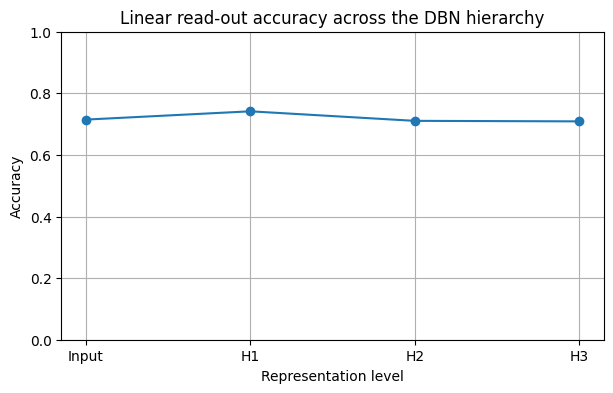

In [40]:
readout_results = pd.DataFrame({
    "Level": ["Input", "H1", "H2", "H3"],
    "Accuracy": [acc_input, acc_h1, acc_h2, acc_h3]
})

print(readout_results)

plt.figure(figsize=(7, 4))
plt.plot(readout_results["Level"], readout_results["Accuracy"], marker="o")
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.xlabel("Representation level")
plt.title("Linear read-out accuracy across the DBN hierarchy")
plt.grid(True)
plt.show()

### Interpretation: linear read-outs

The linear read-out analysis compares how easily the letter classes can be separated from different representation levels: the standardized input pixels and the three DBN hidden layers.

The input read-out gives a baseline accuracy of about `0.715`. The first hidden layer reaches the highest accuracy, about `0.742`, suggesting that H1 learns features that make the letters slightly more linearly separable than in the original pixel space.

However, the deeper representations do not further improve classification performance. H2 reaches about `0.711` and H3 about `0.709`, which are slightly below the input baseline and clearly below H1. Therefore, it's clear that linear separability doesn't  increases monotonically across the DBN hierarchy.

This could be because most of the class-relevant information useful for a linear classifier is already extracted in the first hidden layer. Deeper layers may combine and transform these features into more compressed or abstract representations, but this does not necessarily make the letter classes easier to separate linearly.

This result is important because the read-out model is intentionally simple and the DBN weights are kept fixed. Therefore, the differences in accuracy mainly reflect the quality of the learned representations, rather than the power of a complex supervised classifier.

### without standardizing 

In [41]:
linear_epochs = 1500
linear_lr = 0.05

# Input pixels without standardization
x_train_raw = x_train.view(x_train.shape[0], -1).float()
x_test_raw = x_test.view(x_test.shape[0], -1).float()

# Reinitialize new read-outs for the non-standardized comparison
linear_input_raw = LinearModel(x_train_raw.shape[1], num_classes).to(device)
linear1_raw = LinearModel(h1_train.shape[1], num_classes).to(device)
linear2_raw = LinearModel(h2_train.shape[1], num_classes).to(device)
linear3_raw = LinearModel(h3_train.shape[1], num_classes).to(device)

print("Training input read-out without standardization")
train_readout(linear_input_raw, x_train_raw, y_train, epochs=linear_epochs, lr=linear_lr)

print("Training H1 read-out without standardization")
train_readout(linear1_raw, h1_train, y_train, epochs=linear_epochs, lr=linear_lr)

print("Training H2 read-out without standardization")
train_readout(linear2_raw, h2_train, y_train, epochs=linear_epochs, lr=linear_lr)

print("Training H3 read-out without standardization")
train_readout(linear3_raw, h3_train, y_train, epochs=linear_epochs, lr=linear_lr)

Training input read-out without standardization
epoch :    1/1500, loss = 3.2755
epoch :  101/1500, loss = 2.0480
epoch :  201/1500, loss = 1.6878
epoch :  301/1500, loss = 1.5309
epoch :  401/1500, loss = 1.4420
epoch :  501/1500, loss = 1.3833
epoch :  601/1500, loss = 1.3408
epoch :  701/1500, loss = 1.3082
epoch :  801/1500, loss = 1.2821
epoch :  901/1500, loss = 1.2606
epoch : 1001/1500, loss = 1.2425
epoch : 1101/1500, loss = 1.2271
epoch : 1201/1500, loss = 1.2136
epoch : 1301/1500, loss = 1.2018
epoch : 1401/1500, loss = 1.1914
Training H1 read-out without standardization
epoch :    1/1500, loss = 3.3374
epoch :  101/1500, loss = 1.8535
epoch :  201/1500, loss = 1.5014
epoch :  301/1500, loss = 1.3546
epoch :  401/1500, loss = 1.2706
epoch :  501/1500, loss = 1.2140
epoch :  601/1500, loss = 1.1721
epoch :  701/1500, loss = 1.1392
epoch :  801/1500, loss = 1.1124
epoch :  901/1500, loss = 1.0898
epoch : 1001/1500, loss = 1.0705
epoch : 1101/1500, loss = 1.0536
epoch : 1201/150

In [44]:
with torch.no_grad():
    pred_input_test_raw = linear_input_raw(x_test_raw)
    pred_h1_test_raw = linear1_raw(h1_test)
    pred_h2_test_raw = linear2_raw(h2_test)
    pred_h3_test_raw = linear3_raw(h3_test)

acc_input_raw = compute_accuracy(pred_input_test_raw, y_test)
acc_h1_raw = compute_accuracy(pred_h1_test_raw, y_test)
acc_h2_raw = compute_accuracy(pred_h2_test_raw, y_test)
acc_h3_raw = compute_accuracy(pred_h3_test_raw, y_test)

print("Accuracy input read-out without standardization: {:.3f}".format(acc_input_raw))
print("Accuracy H1 read-out without standardization: {:.3f}".format(acc_h1_raw))
print("Accuracy H2 read-out without standardization: {:.3f}".format(acc_h2_raw))
print("Accuracy H3 read-out without standardization: {:.3f}".format(acc_h3_raw))

raw_readout_results = pd.DataFrame({
    "Level": ["Input", "H1", "H2", "H3"],
    "Accuracy without standardization": [
        acc_input_raw,
        acc_h1_raw,
        acc_h2_raw,
        acc_h3_raw
    ]
})

print(raw_readout_results)

Accuracy input read-out without standardization: 0.668
Accuracy H1 read-out without standardization: 0.701
Accuracy H2 read-out without standardization: 0.671
Accuracy H3 read-out without standardization: 0.681
   Level  Accuracy without standardization
0  Input                          0.667644
1     H1                          0.701394
2     H2                          0.671202
3     H3                          0.680769


   Level  Standardized  Non-standardized
0  Input      0.714712          0.667644
1     H1      0.741587          0.701394
2     H2      0.710625          0.671202
3     H3      0.708942          0.680769


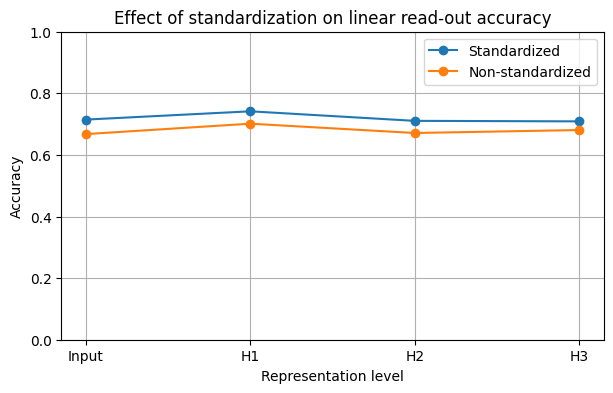

In [45]:
comparison_readout_results = pd.DataFrame({
    "Level": ["Input", "H1", "H2", "H3"],
    "Standardized": [acc_input, acc_h1, acc_h2, acc_h3],
    "Non-standardized": [acc_input_raw, acc_h1_raw, acc_h2_raw, acc_h3_raw]
})

print(comparison_readout_results)

plt.figure(figsize=(7, 4))

plt.plot(
    comparison_readout_results["Level"],
    comparison_readout_results["Standardized"],
    marker="o",
    label="Standardized"
)

plt.plot(
    comparison_readout_results["Level"],
    comparison_readout_results["Non-standardized"],
    marker="o",
    label="Non-standardized"
)

plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.xlabel("Representation level")
plt.title("Effect of standardization on linear read-out accuracy")
plt.grid(True)
plt.legend()
plt.show()

### Control analysis: effect of standardization

As a methodological sanity check, I also trained the linear read-outs on the non-standardized representations. The results show that standardization improves accuracy at all representation levels, with a gap of approximately 3–5 percentage points.

Importantly, the main conclusion remains stable: H1 is the best-performing representation both with and without standardization. This suggests that the advantage of H1 is not an artifact introduced by the standardization procedure.

At the same time, the exact ranking of the other levels changes slightly between the two conditions. Therefore, standardization does influence the absolute performance of the read-outs, probably because SGD with a fixed learning rate optimizes more efficiently when features have comparable scales.

Overall, I keep the standardized read-outs as the main analysis, because they provide a more controlled comparison across representation levels. The non-standardized comparison is used as a control showing that the core finding, namely the stronger linear separability of H1, is robust to this preprocessing choice.

## 10

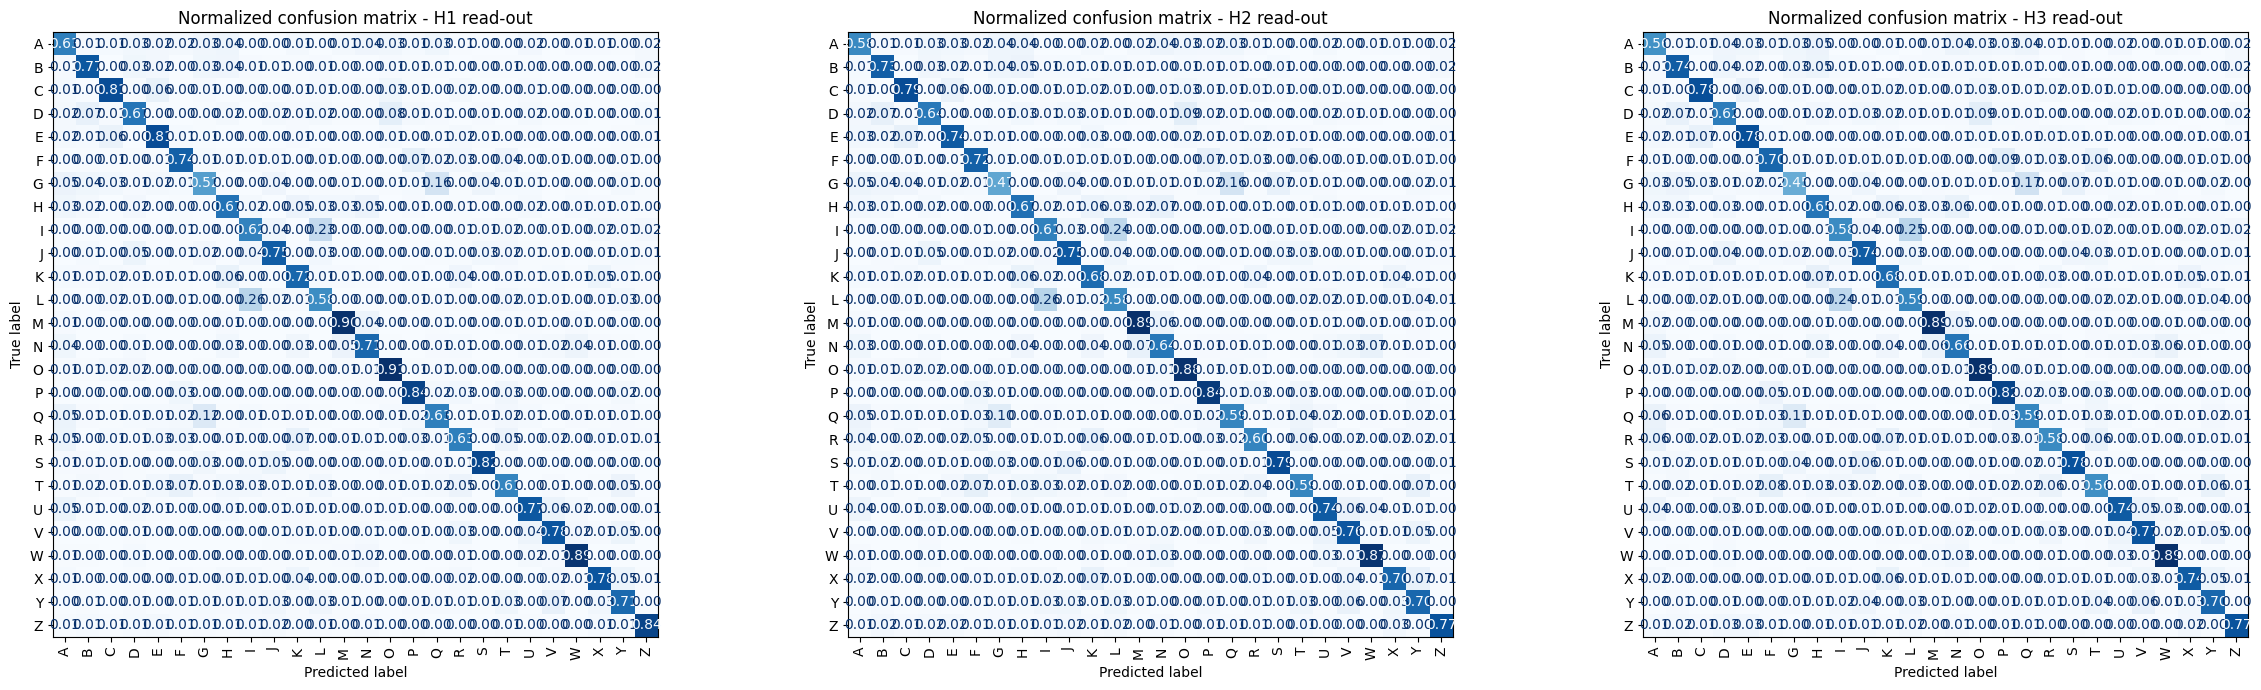


Most frequent normalized confusions - H1 read-out:
True L predicted as I: 0.26
True I predicted as L: 0.23
True G predicted as Q: 0.16
True Q predicted as G: 0.12
True D predicted as O: 0.08
True F predicted as P: 0.07
True Y predicted as V: 0.07
True R predicted as K: 0.07
True T predicted as F: 0.07
True D predicted as B: 0.07

Most frequent normalized confusions - H2 read-out:
True L predicted as I: 0.26
True I predicted as L: 0.24
True G predicted as Q: 0.16
True Q predicted as G: 0.10
True D predicted as O: 0.09
True T predicted as F: 0.07
True F predicted as P: 0.07
True E predicted as C: 0.07
True D predicted as B: 0.07
True T predicted as Y: 0.07

Most frequent normalized confusions - H3 read-out:
True I predicted as L: 0.25
True L predicted as I: 0.24
True G predicted as Q: 0.17
True Q predicted as G: 0.11
True D predicted as O: 0.09
True F predicted as P: 0.09
True T predicted as F: 0.08
True K predicted as H: 0.07
True G predicted as S: 0.07
True D predicted as B: 0.07


In [42]:
# 10. Confusion matrices across hidden representations
#
# Instead of plotting only the H3 confusion matrix, I compare the errors made
# by linear read-outs trained on H1, H2 and H3.

with torch.no_grad():
    predictions_by_layer = {
        "H1": linear1(h1_test_scaled),
        "H2": linear2(h2_test_scaled),
        "H3": linear3(h3_test_scaled)
    }

predicted_classes_by_layer = {}

for layer_name, predictions in predictions_by_layer.items():
    predicted_classes_by_layer[layer_name] = predictions.max(axis=1).indices


# Plot normalized confusion matrices side by side

fig, axes = plt.subplots(1, 3, figsize=(24, 7))

confusion_matrices = {}

for ax, layer_name in zip(axes, ["H1", "H2", "H3"]):

    cm_normalized = confusion_matrix(
        y_test.detach().cpu().numpy(),
        predicted_classes_by_layer[layer_name].detach().cpu().numpy(),
        normalize="true"
    )

    confusion_matrices[layer_name] = cm_normalized

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm_normalized,
        display_labels=class_names
    )

    disp.plot(
        ax=ax,
        cmap="Blues",
        xticks_rotation=90,
        values_format=".2f",
        colorbar=False
    )

    ax.set_title("Normalized confusion matrix - {} read-out".format(layer_name))

plt.tight_layout()
plt.show()


# Print the most frequent errors for each layer

def print_most_frequent_errors(cm_normalized, layer_name, top_k=10):
    cm_errors = cm_normalized.copy()
    np.fill_diagonal(cm_errors, 0)

    errors = []

    for true_label in range(num_classes):
        for predicted_label in range(num_classes):
            error_value = cm_errors[true_label, predicted_label]

            if error_value > 0:
                errors.append((
                    class_names[true_label],
                    class_names[predicted_label],
                    error_value
                ))

    errors = sorted(errors, key=lambda x: x[2], reverse=True)

    print("\nMost frequent normalized confusions - {} read-out:".format(layer_name))

    for true_letter, predicted_letter, value in errors[:top_k]:
        print("True {} predicted as {}: {:.2f}".format(
            true_letter,
            predicted_letter,
            value
        ))


for layer_name in ["H1", "H2", "H3"]:
    print_most_frequent_errors(
        confusion_matrices[layer_name],
        layer_name,
        top_k=10
    )

### Interpretation: normalized confusion matrices

The normalized confusion matrices show that most letters are classified correctly, as indicated by the high values on the diagonal. The off-diagonal values highlight the main errors made by the read-outs trained on H1, H2 and H3.

The strongest and most stable confusion is between `I` and `L`. In the H1 read-out, true `I` is predicted as `L` in 0.25 of the cases, and true `L` is predicted as `I` in 0.25 of the cases. The same pattern remains almost unchanged in H2 and H3, where the corresponding values are about 0.24–0.25. This is visually plausible, because handwritten `I` and `L` can both appear as simple vertical strokes, especially when the horizontal part of `L` is weak or ambiguous.

Another recurrent confusion is between `G` and `Q`. In H1, true `G` is predicted as `Q` in 0.15 of the cases, while true `Q` is predicted as `G` in 0.12 of the cases. This pair is also among the strongest errors in H2 and H3. This makes sense visually, because both letters have a rounded global shape and may differ only by a small stroke or tail.

Other frequent errors include pairs such as `D-O`, `F-P`, `C-E`, `K-H`, `R-K` and `Q-A`. These errors are smaller than the `I-L` confusion, but they are still meaningful because they involve letters with similar global shapes or stroke configurations.

An important result is that the main error patterns are very similar across H1, H2 and H3. This suggests that deeper hidden representations do not completely remove the visual ambiguities between some handwritten letters. Instead, the DBN seems to preserve a structured organization of visual similarity across layers.

Overall, the model does not make random errors. Most mistakes are concentrated between visually similar letters, and this is coherent with the clustering results, where some of the same pairs, such as `I-L`, `G-Q` and `F-P`, also appear close in the hidden representation space.

### Psychometric curves: robustness to noise

In this section, I test how the H3 read-out behaves when the test images are progressively corrupted. I use two types of noise: Gaussian noise and salt-and-pepper noise. Gaussian noise adds continuous random perturbations to the pixels, while salt-and-pepper noise randomly replaces some pixels with black or white values.

The goal is to obtain psychometric curves, where accuracy is plotted as a function of noise level. This allows me to see whether performance decreases gradually or abruptly when the visual input becomes less reliable.

In [43]:
# 11. Psychometric curves: robustness to noise
#
# two image distortions are being tested:
# - Gaussian noise: continuous random perturbations added to pixels
# - salt-and-pepper noise: random pixels replaced by 0 or 1
#
# This allows to check how gradually the model performance decreases
# as the input images become more corrupted.

def inject_gaussian_noise(data, noise_level):
    noise = torch.randn(data.shape, device=data.device) * noise_level
    noisy_data = data + noise
    noisy_data = torch.clamp(noisy_data, 0, 1)
    return noisy_data


def inject_salt_pepper_noise(data, noise_level):
    # noise_level is the probability that each pixel is replaced by 0 or 1
    random_mask = torch.rand(data.shape, device=data.device) < noise_level
    random_pixels = torch.randint(0, 2, data.shape, device=data.device).float()

    noisy_data = torch.where(random_mask, random_pixels, data)
    return noisy_data

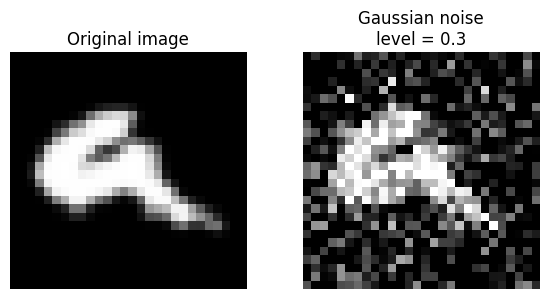

In [44]:
# Example of Gaussian noise

noise_level = 0.3
x_test_noisy = inject_gaussian_noise(x_test, noise_level)

fig, axes = plt.subplots(1, 2, figsize=(6, 3))

axes[0].imshow(x_test[0].detach().cpu(), cmap="gray")
axes[0].set_title("Original image")
axes[0].axis("off")

axes[1].imshow(x_test_noisy[0].detach().cpu(), cmap="gray")
axes[1].set_title("Gaussian noise\nlevel = {}".format(noise_level))
axes[1].axis("off")

plt.tight_layout()
plt.show()

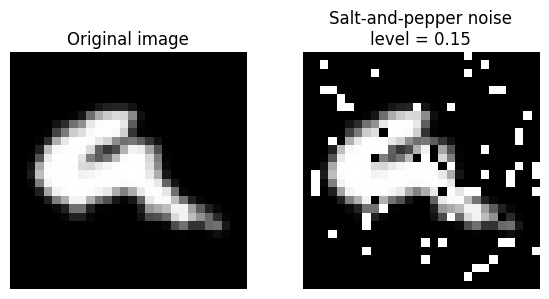

In [45]:
# Example of salt-and-pepper noise

noise_level = 0.15
x_test_sp = inject_salt_pepper_noise(x_test, noise_level)

fig, axes = plt.subplots(1, 2, figsize=(6, 3))

axes[0].imshow(x_test[0].detach().cpu(), cmap="gray")
axes[0].set_title("Original image")
axes[0].axis("off")

axes[1].imshow(x_test_sp[0].detach().cpu(), cmap="gray")
axes[1].set_title("Salt-and-pepper noise\nlevel = {}".format(noise_level))
axes[1].axis("off")

plt.tight_layout()
plt.show()

The examples confirm that the two noise types affect the image in structurally different ways. Gaussian noise spreads continuous perturbations across the whole image, degrading both the letter and the background. Salt-and-pepper noise instead randomly replaces isolated pixels with extreme black or white values, producing a sparser but potentially disruptive corruption.

These differences are important because the two types of noise may stress the model in different ways. The psychometric curves will test whether the read-outs degrade similarly under both distortions or whether one type of noise is more harmful than the other.

### Evaluation on noisy images

To build the psychometric curves, I evaluate the same read-outs on progressively corrupted test images. For each noise level,has been computed the accuracy of the input, H1, H2 and H3 read-outs and reuse the standardization statistics computed on the clean training set, so the noisy test images are evaluated with the same preprocessing used before.

In [46]:
# 11. Psychometric curves with multiple noise seeds

def evaluate_readouts_on_images(images):
    with torch.no_grad():

        # Input read-out
        images_flat = images.reshape(images.shape[0], -1)
        images_flat_scaled = apply_standardizer(
            images_flat,
            input_stats["mean"],
            input_stats["std"]
        )

        pred_input = linear_input(images_flat_scaled)
        acc_input = compute_accuracy(pred_input, y_test)

        # Hidden representations
        h1 = get_kth_layer_repr(images, 0, device)
        h2 = get_kth_layer_repr(h1, 1, device)
        h3 = get_kth_layer_repr(h2, 2, device)

        h1_scaled = apply_standardizer(h1, h1_stats["mean"], h1_stats["std"])
        h2_scaled = apply_standardizer(h2, h2_stats["mean"], h2_stats["std"])
        h3_scaled = apply_standardizer(h3, h3_stats["mean"], h3_stats["std"])

        pred_h1 = linear1(h1_scaled)
        pred_h2 = linear2(h2_scaled)
        pred_h3 = linear3(h3_scaled)

        acc_h1 = compute_accuracy(pred_h1, y_test)
        acc_h2 = compute_accuracy(pred_h2, y_test)
        acc_h3 = compute_accuracy(pred_h3, y_test)

    return {
        "Input": acc_input,
        "H1": acc_h1,
        "H2": acc_h2,
        "H3": acc_h3
    }


def evaluate_noise_curve(noise_function, noise_levels, seeds):
    rows = []

    for noise_level in noise_levels:
        accuracies = {
            "Input": [],
            "H1": [],
            "H2": [],
            "H3": []
        }

        for seed in seeds:
            torch.manual_seed(seed)
            np.random.seed(seed)

            if torch.cuda.is_available():
                torch.cuda.manual_seed_all(seed)

            noisy_images = noise_function(x_test, float(noise_level))
            results = evaluate_readouts_on_images(noisy_images)

            for representation_name in accuracies:
                accuracies[representation_name].append(results[representation_name])

        for representation_name in accuracies:
            values = np.array(accuracies[representation_name])

            rows.append({
                "noise_level": float(noise_level),
                "representation": representation_name,
                "mean_accuracy": values.mean(),
                "std_accuracy": values.std()
            })

    return pd.DataFrame(rows)


def plot_noise_curve(results, title):
    plt.figure(figsize=(8, 5))

    for representation_name in ["Input", "H1", "H2", "H3"]:
        subset = results[results["representation"] == representation_name]
        subset = subset.sort_values("noise_level")

        noise_levels = subset["noise_level"].values
        mean_accuracy = subset["mean_accuracy"].values
        std_accuracy = subset["std_accuracy"].values

        line = plt.plot(
            noise_levels,
            mean_accuracy,
            marker="o",
            label=representation_name
        )[0]

        plt.fill_between(
            noise_levels,
            mean_accuracy - std_accuracy,
            mean_accuracy + std_accuracy,
            alpha=0.15,
            color=line.get_color()
        )

    plt.axhline(
        1 / num_classes,
        linestyle=":",
        color="gray",
        label="Chance level"
    )

    plt.title(title)
    plt.xlabel("Noise level")
    plt.ylabel("Accuracy")
    plt.ylim(0, 1)
    plt.grid(True)
    plt.legend()
    plt.show()

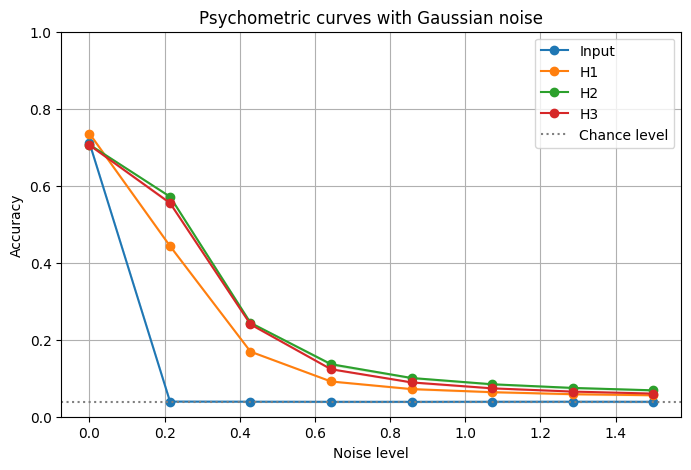

representation,H1,H2,H3,Input
noise_level,,,,
0.000000,0.736,0.707,0.705,0.711
0.214286,0.443,0.572,0.555,0.039
0.428571,0.169,0.244,0.240,0.039
0.642857,0.092,0.136,0.123,0.039
0.857143,0.072,0.101,0.089,0.039
1.071429,0.064,0.084,0.074,0.039
1.285714,0.059,0.075,0.065,0.039
1.500000,0.056,0.069,0.060,0.039


In [47]:
noise_seeds = [0, 1, 2, 3, 4]

gaussian_noise_levels = np.linspace(0, 1.5, 8)

gaussian_results = evaluate_noise_curve(
    noise_function=inject_gaussian_noise,
    noise_levels=gaussian_noise_levels,
    seeds=noise_seeds
)

plot_noise_curve(
    gaussian_results,
    title="Psychometric curves with Gaussian noise"
)

display(
    gaussian_results
    .pivot(index="noise_level", columns="representation", values="mean_accuracy")
    .round(3)
)

### Interpretation: Gaussian noise psychometric curve

This curve shows how classification accuracy changes when the test images are progressively degraded by Gaussian noise. The important point is not only the final accuracy, but also the shape of the curve. A gradual decrease would indicate some robustness to noise, while a rapid collapse would suggest fragility to pixel-level distortions.

In this case, the input read-out is the most fragile one. Its accuracy drops from about 0.71 on clean images to almost chance level already at the first noise level. This drop is quite abrupt, rather than gradual, which suggests that a linear classifier trained directly on raw pixels is highly sensitive to continuous pixel-level perturbations.

The DBN hidden read-outs are more robust at low and moderate Gaussian noise levels. At noise level 0.21, H1, H2 and H3 still obtain accuracies around 0.54–0.58, while the input read-out is already close to chance. In contrast to the input read-out, the hidden-layer curves decrease more smoothly, suggesting that the DBN representations are less directly tied to individual pixel values.

However, this robustness is limited. As the noise level increases, all read-outs progressively approach chance performance. H3 is slightly better than the other hidden layers at some noise levels, but the difference is small, so I would not claim a strong advantage of the deepest layer. Overall, the main result is that the DBN representations improve robustness compared to raw pixels, especially for low and moderate Gaussian noise.

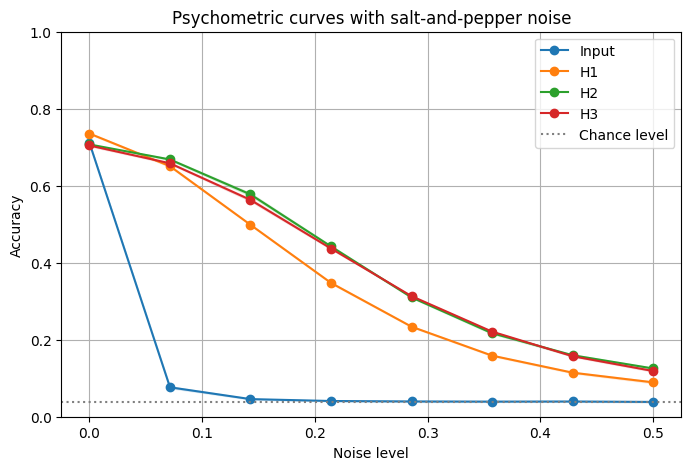

representation,H1,H2,H3,Input
noise_level,,,,
0.000000,0.736,0.707,0.704,0.711
0.071429,0.651,0.668,0.658,0.076
0.142857,0.498,0.577,0.563,0.046
0.214286,0.348,0.442,0.437,0.041
0.285714,0.234,0.310,0.313,0.040
0.357143,0.159,0.217,0.221,0.039
0.428571,0.114,0.160,0.157,0.040
0.500000,0.089,0.125,0.119,0.038


In [48]:
salt_pepper_noise_levels = np.linspace(0, 0.5, 8)

salt_pepper_results = evaluate_noise_curve(
    noise_function=inject_salt_pepper_noise,
    noise_levels=salt_pepper_noise_levels,
    seeds=noise_seeds
)

plot_noise_curve(
    salt_pepper_results,
    title="Psychometric curves with salt-and-pepper noise"
)

display(
    salt_pepper_results
    .pivot(index="noise_level", columns="representation", values="mean_accuracy")
    .round(3)
)

### Interpretation: salt-and-pepper noise psychometric curve

Salt-and-pepper noise affects the image differently from Gaussian noise, because it randomly replaces individual pixels with black or white values. This can be disruptive for handwritten letters, especially when corrupted pixels overlap with important strokes.

The input read-out is again very fragile. Its accuracy drops from about 0.71 on clean images to about 0.08 already at noise level 0.07, and then remains close to chance level. This shows that a linear classifier trained directly on raw pixels is strongly affected even by a small amount of salt-and-pepper corruption.

The DBN hidden read-outs are much more robust. At noise level 0.07, H1, H2 and H3 still remain around 0.70–0.73. As the noise level increases, their performance decreases more gradually: at noise level 0.21 they are still around 0.43–0.46, and only at higher levels do they approach low accuracy values. H1 decreases slightly faster than H2 and H3 at some noise levels, but the differences between the three hidden layers remain small overall.

Compared with Gaussian noise, the same general pattern holds: the raw input read-out collapses very quickly, while the DBN representations degrade more gradually. However, the two noise levels are not directly comparable, because Gaussian noise level controls the strength of continuous perturbations, while salt-and-pepper noise level controls the probability of replacing pixels. In both cases, the result is consistent: the DBN hidden representations preserve useful information better than the raw pixel representation.

Overall, the psychometric curves under both noise types support the same conclusion: the DBN learns representations that are more robust to visual degradation than raw pixels, especially at low and moderate noise levels. However, this robustness is limited, because when the corruption becomes strong enough, all read-outs move toward poor performance.

### Feed-forward baseline

This model is trained in a fully supervised end-to-end way. I use it as a baseline to compare with the DBN representations evaluated through linear read-outs.

The comparison is not perfectly equivalent, because the feed-forward network learns its hidden layers directly from the labels, whereas the DBN learns its representations through unsupervised pre-training and only later evaluates them with simple supervised classifiers.

In [49]:
# 12. Feed-forward baseline
#
# This model is trained in a fully supervised end-to-end way.
# I use it as a baseline for comparison with the DBN representations + linear read-outs.
# The comparison is not perfectly equivalent, because the FFNN uses labels during the whole training,
# while the DBN learns its hidden representations through unsupervised pre-training.

class Feedforward(torch.nn.Module):
    def __init__(self, first_hidden_layer_size, second_hidden_layer_size, third_hidden_layer_size, num_classes):
        super().__init__()

        self.first_hidden = torch.nn.Linear(784, first_hidden_layer_size)
        self.second_hidden = torch.nn.Linear(first_hidden_layer_size, second_hidden_layer_size)
        self.third_hidden = torch.nn.Linear(second_hidden_layer_size, third_hidden_layer_size)
        self.output = torch.nn.Linear(third_hidden_layer_size, num_classes)
        self.relu = torch.nn.ReLU()

    def forward(self, input_data):
        first_hidden_repr = self.relu(self.first_hidden(input_data))
        second_hidden_repr = self.relu(self.second_hidden(first_hidden_repr))
        third_hidden_repr = self.relu(self.third_hidden(second_hidden_repr))

        output = self.output(third_hidden_repr)
        return output

In [50]:
def train_feedforward(network, images, labels, epochs=30, batch_size=256, lr=0.001):
    images_flat = images.reshape(images.shape[0], -1)
    train_dataset = TensorDataset(images_flat, labels)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    optimizer = torch.optim.Adam(network.parameters(), lr=lr)
    loss_fn = torch.nn.CrossEntropyLoss()

    for epoch in range(epochs):
        network.train()
        epoch_loss = 0

        for batch_images, batch_labels in train_loader:
            batch_images = batch_images.to(device)
            batch_labels = batch_labels.to(device)

            optimizer.zero_grad()

            predictions = network(batch_images)
            loss = loss_fn(predictions, batch_labels)

            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        if epoch % 5 == 0:
            print("epoch : {:3d}/{}, loss = {:.4f}".format(
                epoch + 1,
                epochs,
                epoch_loss / len(train_loader)
            ))


def evaluate_feedforward(network, images, labels):
    network.eval()

    with torch.no_grad():
        images_flat = images.reshape(images.shape[0], -1).to(device)
        labels = labels.to(device)

        predictions = network(images_flat)
        accuracy = compute_accuracy(predictions, labels)

    return accuracy

In [51]:
ffnn = Feedforward(
    selected_hidden_units[0],
    selected_hidden_units[1],
    selected_hidden_units[2],
    num_classes
).to(device)

train_feedforward(ffnn, x_train, y_train, epochs=30, batch_size=256, lr=0.001)

ffnn_test_accuracy = evaluate_feedforward(ffnn, x_test, y_test)
print("Feed-forward test accuracy: {:.3f}".format(ffnn_test_accuracy))

epoch :   1/30, loss = 0.7146
epoch :   6/30, loss = 0.1605
epoch :  11/30, loss = 0.1038
epoch :  16/30, loss = 0.0801
epoch :  21/30, loss = 0.0694
epoch :  26/30, loss = 0.0581
Feed-forward test accuracy: 0.919


### Interpretation: feed-forward baseline

The feed-forward network reaches a high test accuracy, around 0.91. This is higher than the DBN linear read-outs on the same task , which is expected because the FFNN is trained end-to-end using the class labels.

This result should not be interpreted as showing that the DBN is worse in every sense. The two models have different roles in the project: the FFNN provides a strong supervised baseline, while the DBN is mainly used to study how unsupervised hidden representations are organized and how robust they are under different perturbations.

In [52]:
# 13. Adversarial attacks with FGSM
#
# I compare the supervised FFNN with the DBN read-outs from H1, H2 and H3.
# The attack is white-box, because each model is attacked using its own gradient.

def fgsm_attack(images, epsilon, gradient):
    perturbed_images = images + epsilon * gradient.sign()
    perturbed_images = torch.clamp(perturbed_images, 0, 1)
    return perturbed_images


def forward_model(model_name, images):

    if model_name == "FFNN":
        images_flat = images.reshape(images.shape[0], -1)
        return ffnn(images_flat)

    h1 = get_kth_layer_repr(images, 0, device)
    h2 = get_kth_layer_repr(h1, 1, device)
    h3 = get_kth_layer_repr(h2, 2, device)

    if model_name == "DBN + H1":
        h1_scaled = apply_standardizer(h1, h1_stats["mean"], h1_stats["std"])
        return linear1(h1_scaled)

    if model_name == "DBN + H2":
        h2_scaled = apply_standardizer(h2, h2_stats["mean"], h2_stats["std"])
        return linear2(h2_scaled)

    if model_name == "DBN + H3":
        h3_scaled = apply_standardizer(h3, h3_stats["mean"], h3_stats["std"])
        return linear3(h3_scaled)


def evaluate_fgsm(model_name, epsilon):
    images = x_test.clone().detach().to(device)
    labels = y_test.to(device)

    images.requires_grad_(True)

    outputs = forward_model(model_name, images)
    loss = functional.cross_entropy(outputs, labels)

    ffnn.zero_grad()
    linear1.zero_grad()
    linear2.zero_grad()
    linear3.zero_grad()

    loss.backward()

    gradient = images.grad.data
    adversarial_images = fgsm_attack(images, epsilon, gradient)

    with torch.no_grad():
        adversarial_outputs = forward_model(model_name, adversarial_images)
        predictions = adversarial_outputs.max(axis=1).indices
        accuracy = (predictions == labels).float().mean().item()

    return accuracy

In [53]:
epsilon_values = [0, 0.03, 0.06, 0.09, 0.12, 0.15, 0.20, 0.25]

model_names = [
    "FFNN",
    "DBN + H1",
    "DBN + H2",
    "DBN + H3"
]

attack_results = []

for model_name in model_names:
    for epsilon in epsilon_values:
        accuracy = evaluate_fgsm(model_name, epsilon)

        attack_results.append({
            "model": model_name,
            "epsilon": epsilon,
            "accuracy": accuracy
        })

        print("{} | epsilon = {:.2f} | accuracy = {:.3f}".format(
            model_name,
            epsilon,
            accuracy
        ))

attack_results = pd.DataFrame(attack_results)
display(attack_results)

FFNN | epsilon = 0.00 | accuracy = 0.919
FFNN | epsilon = 0.03 | accuracy = 0.707
FFNN | epsilon = 0.06 | accuracy = 0.449
FFNN | epsilon = 0.09 | accuracy = 0.283
FFNN | epsilon = 0.12 | accuracy = 0.195
FFNN | epsilon = 0.15 | accuracy = 0.145
FFNN | epsilon = 0.20 | accuracy = 0.104
FFNN | epsilon = 0.25 | accuracy = 0.082


AttributeError: 'NoneType' object has no attribute 'data'

In [ ]:
plt.figure(figsize=(8, 5))

for model_name in model_names:
    subset = attack_results[attack_results["model"] == model_name]

    plt.plot(
        subset["epsilon"],
        subset["accuracy"],
        marker="o",
        label=model_name
    )

plt.axhline(
    1 / num_classes,
    linestyle=":",
    color="gray",
    label="Chance level"
)

plt.xlabel("FGSM epsilon")
plt.ylabel("Accuracy")
plt.title("White-box FGSM robustness")
plt.ylim(0, 1)
plt.grid(True)
plt.legend()
plt.show()

fino a qui abbiamo la versione compatta, che non divide il test set in parti.
da sotto in poi c'è la versione in batch in cui viene diviso il test set x_test

In [ ]:
# 13. Adversarial attacks with FGSM
#
# I compare the supervised FFNN with the DBN read-outs from H1, H2 and H3.
# The attack is white-box, because each model is attacked using its own gradient.
# This version processes the test set in mini-batches to reduce memory usage.

def fgsm_attack(images, epsilon, gradient):
    perturbed_images = images + epsilon * gradient.sign()
    perturbed_images = torch.clamp(perturbed_images, 0, 1)
    return perturbed_images


def forward_model(model_name, images):

    if model_name == "FFNN":
        images_flat = images.reshape(images.shape[0], -1)
        return ffnn(images_flat)

    h1 = get_kth_layer_repr(images, 0, device)

    if model_name == "DBN + H1":
        h1_scaled = apply_standardizer(h1, h1_stats["mean"], h1_stats["std"])
        return linear1(h1_scaled)

    h2 = get_kth_layer_repr(h1, 1, device)

    if model_name == "DBN + H2":
        h2_scaled = apply_standardizer(h2, h2_stats["mean"], h2_stats["std"])
        return linear2(h2_scaled)

    h3 = get_kth_layer_repr(h2, 2, device)

    if model_name == "DBN + H3":
        h3_scaled = apply_standardizer(h3, h3_stats["mean"], h3_stats["std"])
        return linear3(h3_scaled)


def zero_model_gradients():
    ffnn.zero_grad()
    linear1.zero_grad()
    linear2.zero_grad()
    linear3.zero_grad()

    for rbm_layer in dbn_emnist.rbm_layers:
        if hasattr(rbm_layer, "zero_grad"):
            rbm_layer.zero_grad()


def evaluate_fgsm_batched(model_name, epsilon, batch_size=256):
    test_dataset = TensorDataset(x_test, y_test)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    correct = 0
    total = 0

    for batch_images, batch_labels in test_loader:
        batch_images = batch_images.clone().detach().to(device)
        batch_labels = batch_labels.to(device)

        batch_images.requires_grad_(True)

        outputs = forward_model(model_name, batch_images)
        loss = functional.cross_entropy(outputs, batch_labels)

        zero_model_gradients()
        loss.backward()

        gradient = batch_images.grad.data
        adversarial_images = fgsm_attack(batch_images, epsilon, gradient)

        with torch.no_grad():
            adversarial_outputs = forward_model(model_name, adversarial_images)
            predictions = adversarial_outputs.max(axis=1).indices

        correct += (predictions == batch_labels).sum().item()
        total += batch_labels.shape[0]

    accuracy = correct / total

    return accuracy

In [ ]:
epsilon_values = [0, 0.03, 0.06, 0.09, 0.12, 0.15, 0.20, 0.25]

model_names = [
    "FFNN",
    "DBN + H1",
    "DBN + H2",
    "DBN + H3"
]

attack_results = []

for model_name in model_names:
    print("\nEvaluating:", model_name)

    for epsilon in epsilon_values:
        accuracy = evaluate_fgsm_batched(
            model_name=model_name,
            epsilon=epsilon,
            batch_size=256
        )

        attack_results.append({
            "model": model_name,
            "epsilon": epsilon,
            "accuracy": accuracy
        })

        print("{} | epsilon = {:.2f} | accuracy = {:.3f}".format(
            model_name,
            epsilon,
            accuracy
        ))

attack_results = pd.DataFrame(attack_results)

display(attack_results)

In [ ]:
plt.figure(figsize=(8, 5))

for model_name in model_names:
    subset = attack_results[attack_results["model"] == model_name]

    plt.plot(
        subset["epsilon"],
        subset["accuracy"],
        marker="o",
        label=model_name
    )

plt.axhline(
    1 / num_classes,
    linestyle=":",
    color="gray",
    label="Chance level"
)

plt.xlabel("FGSM epsilon")
plt.ylabel("Accuracy")
plt.title("White-box FGSM robustness")
plt.ylim(0, 1)
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
# Sanity check:
# when epsilon = 0, the FGSM evaluation should reproduce the clean accuracy
# of each model.

sanity_check = attack_results[attack_results["epsilon"] == 0]
sanity_check = sanity_check[["model", "accuracy"]]

display(sanity_check)

### Interpretation: white-box FGSM attacks

Here each model is attacked using its own gradient. This is a stronger test than simply adding random noise, because the perturbation is chosen to increase the classification loss.

After running the notebook, I should compare the slope of the FFNN curve and the DBN+readout curve. If one curve drops more slowly, that model is more robust under this specific attack setup.

In [ ]:
# 14. Transfer attack: adversarial images generated on FFNN and tested on DBN
#
# In the previous section, each model was attacked directly.
# Here I generate FGSM images using the FFNN gradient and then test the same
# perturbed images on both the FFNN and the DBN+readout.
#
# This is useful because it checks whether adversarial examples for a purely
# discriminative model also transfer to the DBN representation.

def evaluate_transfer_attack_from_ffnn(ffnn_model, images, labels, epsilon, batch_size=256):
    ffnn_model.eval()

    test_dataset = TensorDataset(images, labels)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    correct_ffnn = 0
    correct_dbn = 0
    total = 0

    for batch_images, batch_labels in tqdm(test_loader):
        batch_images = batch_images.clone().detach().to(device)
        batch_labels = batch_labels.to(device)

        flat_images = batch_images.view(batch_images.shape[0], -1)
        flat_images.requires_grad = True

        # Create adversarial examples using the FFNN.
        output_ffnn = ffnn_model(flat_images)
        loss_value = functional.cross_entropy(output_ffnn, batch_labels)

        ffnn_model.zero_grad()
        loss_value.backward()

        perturbed_flat = fgsm_attack(flat_images, epsilon, flat_images.grad.data).detach()
        perturbed_images = perturbed_flat.view(batch_images.shape[0], 28, 28)

        # Evaluate FFNN on the adversarial images.
        output_ffnn_adv = ffnn_model(perturbed_flat)
        pred_ffnn_adv = output_ffnn_adv.max(axis=1).indices

        # Evaluate DBN+H3 readout on the same adversarial images.
        output_dbn_adv = dbn_h3_readout_forward(perturbed_images)
        pred_dbn_adv = output_dbn_adv.max(axis=1).indices

        correct_ffnn += (pred_ffnn_adv == batch_labels).sum().item()
        correct_dbn += (pred_dbn_adv == batch_labels).sum().item()
        total += len(batch_labels)

    return correct_ffnn / total, correct_dbn / total

In [ ]:
transfer_accuracies_ffnn = []
transfer_accuracies_dbn = []

for epsilon in epsilon_values:
    acc_ffnn_transfer, acc_dbn_transfer = evaluate_transfer_attack_from_ffnn(
        ffnn,
        x_test,
        y_test,
        epsilon
    )

    transfer_accuracies_ffnn.append(acc_ffnn_transfer)
    transfer_accuracies_dbn.append(acc_dbn_transfer)

    print("epsilon = {:.2f}, transfer FFNN accuracy = {:.3f}, transfer DBN+readout accuracy = {:.3f}".format(
        epsilon,
        acc_ffnn_transfer,
        acc_dbn_transfer
    ))

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(epsilon_values, transfer_accuracies_ffnn, marker="o")
plt.plot(epsilon_values, transfer_accuracies_dbn, marker="o")
plt.axhline(1 / num_classes, linestyle=":", color="gray")

plt.xlabel("Strength of FFNN-generated adversarial attack")
plt.ylabel("Accuracy")
plt.title("Transfer attack: FFNN-generated FGSM examples")
plt.legend(["FFNN on attacked images", "DBN + H3 read-out on same images", "Chance level"])
plt.grid(True)
plt.show()

### Interpretation: transfer attack

In this analysis, the adversarial images are generated using the FFNN gradient and then tested on both models. This is useful because it asks whether adversarial examples for a discriminative model also transfer to the DBN representation.

If the DBN+readout keeps higher accuracy on the same perturbed images, this would suggest that its representation is less affected by this specific FFNN-generated perturbation.

In [ ]:
# 15. Simple data augmentation with noisy training
#
# This is not true adversarial training.
# I present it only as a simple data augmentation strategy based on noisy inputs.

ffnn_noisy = Feedforward(
    selected_hidden_units[0],
    selected_hidden_units[1],
    selected_hidden_units[2],
    num_classes
).to(device)

In [ ]:
def train_feedforward_with_noise(network, images, labels, noise_level=0.2, epochs=30, batch_size=256, lr=0.001):
    train_dataset = TensorDataset(images.view(images.shape[0], -1), labels)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    optimizer = torch.optim.Adam(network.parameters(), lr=lr)
    loss_fn = torch.nn.CrossEntropyLoss()

    for epoch in range(epochs):
        network.train()
        epoch_loss = 0

        for batch_images, batch_labels in train_loader:
            noisy_batch = batch_images + torch.randn(batch_images.shape, device=device) * noise_level
            noisy_batch = torch.clamp(noisy_batch, 0, 1)

            optimizer.zero_grad()

            predictions = network(noisy_batch)
            loss = loss_fn(predictions, batch_labels)

            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        if epoch % 5 == 0:
            print("epoch : {:3d}/{}, loss = {:.4f}".format(epoch + 1, epochs, epoch_loss / len(train_loader)))

In [ ]:
train_feedforward_with_noise(
    ffnn_noisy,
    x_train,
    y_train,
    noise_level=0.2,
    epochs=30,
    batch_size=256,
    lr=0.001
)

In [ ]:
attack_accuracies_noisy = []

for epsilon in epsilon_values:
    acc = test_ffnn_robustness_to_attack(ffnn_noisy, x_test, y_test, epsilon)
    attack_accuracies_noisy.append(acc)
    print("epsilon = {:.2f}, noisy-training FFNN accuracy = {:.3f}".format(epsilon, acc))

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(epsilon_values, attack_accuracies_ffnn, marker="o")
plt.plot(epsilon_values, attack_accuracies_noisy, marker="o")
plt.plot(epsilon_values, attack_accuracies_dbn, marker="o")
plt.axhline(1 / num_classes, linestyle=":", color="gray")

plt.xlabel("Strength of adversarial attack")
plt.ylabel("Accuracy")
plt.title("FGSM robustness comparison")
plt.legend(["FFNN", "FFNN with noisy data augmentation", "DBN + H3 read-out", "Chance level"])
plt.grid(True)
plt.show()

### Interpretation: noisy data augmentation

The model trained with noisy images should be described as a simple data augmentation baseline, not as adversarial training. True adversarial training would require generating adversarial examples during training.

After running the notebook, I should check whether noisy data augmentation improves robustness to FGSM, and whether this improvement comes at a cost in clean accuracy.

## Final discussion

After running the whole notebook, this section should contain the final written discussion using the actual values obtained above.

A good final discussion should be written in a personal and concrete style. For example, instead of writing *“the model successfully learns hierarchical representations”*, it is better to write something like:

> I expected H3 to clearly outperform the previous layers, but the difference between H2 and H3 is relatively small. This may mean that most useful information for letter classification is already captured at the intermediate level.

The final discussion should cover:

1. whether the linear read-out accuracy improves from Input to H3;
2. whether the dendrograms group visually similar letters;
3. which letters are most often confused in the normalized confusion matrix;
4. how the psychometric curves change with Gaussian and salt-and-pepper noise;
5. whether DBN+readout is more or less robust than FFNN under FGSM and transfer attacks;
6. the limits of the model, including the simplified nature of EMNIST and the dependence on hyperparameters and training time.

I did not perform an exhaustive architecture search, because the focus of the project was mainly the analysis of the learned representations rather than optimizing classification accuracy. However, the chosen DBN architecture was useful for the project because it provided multiple hidden levels for linear read-outs, clustering, receptive fields and robustness analyses.

In [ ]:
# in dbn architecture: # The goal here is not only to get a classifier, but to inspect whether hidden
# representations become progressively more useful for letter classification

The confusion matrix confirmed that most errors were not random, but involved visually similar letters such as I/L, G/Q and D/O.

The feed-forward network reaches a higher test accuracy than the DBN read-outs. This is expected, because the feed-forward model is trained end-to-end in a fully supervised way, while the DBN hidden representations are learned through unsupervised pre-training and only the final read-out is supervised. For this reason, the feed-forward model is not a direct equivalent of the DBN, but it provides a useful supervised baseline.

The read-out accuracy improves from the raw input pixels to the DBN hidden representations, which suggests that the unsupervised pre-training produces features that are more useful for linear classification. However, the improvement is not strictly monotonic: H2 is slightly lower than H1, while H3 returns to a similar level. This means that deeper layers are not automatically better for classification. Since the DBN is trained with an unsupervised objective, each layer learns to model the structure of the previous representation, not directly to optimize class separability. Therefore, H2 may reorganize the features in a way that is useful for representation learning but slightly less linearly separable with respect to the letter labels.

The model partially supports the idea that hidden representations are more useful than raw pixels, because linear read-outs from the DBN layers outperform the input read-out. However, the improvement is not strictly monotonic across depth, suggesting that deeper unsupervised layers do not automatically guarantee better class disentanglement.

Le rappresentazioni nascoste della DBN migliorano chiaramente rispetto ai pixel grezzi, ma non mostrano una progressione monotona netta. Questo suggerisce che la rete apprende feature utili, ma il grado di disentanglement non aumenta automaticamente con la profondi

The FFNN provides a strong supervised baseline, but it answers a different question. It shows what can be achieved when the whole architecture is optimized for labels. The DBN read-outs instead test whether useful class information emerges from unsupervised representations before direct supervised optimization.